# Regional Downscaling — BCSD + Optuna + Evaluation
**Order:** QM bias-correction @1° → Optuna tunes MLP → MLP downscales to 0.05° → evaluation.

## Run order
Cell 0 (paths) → Cell 1 (dual-res masks + parent map + save-windows; **check plot**) →
Cell 2 (helpers) → **Cell 3 (1° bias correction)** → **Cell 3.5 (Optuna)** →
*Cell 3.6 (optional lr / epochs override — keeps Optuna's architecture)* →
**Cell 4 (MLP: train once + downscale)** → **Cell 5 (evaluation: bar charts + loss curves)**.

## Training (as requested)
- Uses **whatever architecture Optuna selects**.
- **Guaranteed minimum 100 epochs** per monthly model, then early-stops if val RMSE hasn't
  improved for 15 epochs (ceiling 300).
- **Every epoch printed AND saved** to `epoch_mMM.csv`.

## Region-masked inputs ARE saved (`region_masked/`)
Each year's region-masked **1° GCM, 1° CHIRPS, and 0.05° CHIRPS** is written as a compact
bounding-box NetCDF (`gcm1_YYYY.nc`, `chr1_YYYY.nc`, `chr5_YYYY.nc`) and reused on later runs.
(`SAVE_MASKED=True` in Cell 2; set False to disable.)

## Evaluation (Cell 5, up to bar charts)
Per-month loss & val-RMSE curves; **RAW GCM vs BIAS-CORRECTED vs MLP** RMSE and R² vs 0.05°
CHIRPS (per-month bars + overall). Correlation/KGE/distribution/maps come next on request.

## Saved & resumable
`region_masked/*.nc` · `qm1deg_tf.npz` · `optuna_study.db` · `optuna_best_params.json` ·
`optuna_trials_full.csv` · per-month `mlp_mMM.pth`+`scaler_mMM.joblib`+`epoch_mMM.csv` ·
`bc_gcm_1deg_{train,test}.nc` · `downscaled_005_{train,test}.nc` · evaluation PNGs.

## Edit before running — PATHS block in Cell 0 (Kaggle root: /kaggle/input/datasets/kalpitasaha/chirps3)


In [1]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 0 — setup, paths, config   (BCSD order: QM @1° → MLP to 0.05°) ║
# ╚══════════════════════════════════════════════════════════════════════╝
import importlib, subprocess, sys, glob
if importlib.util.find_spec("optuna") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "optuna"])

import os, warnings, json, math
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy.interpolate import RegularGridInterpolator
import joblib
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
# ╔══ EDIT THESE PATHS ════════════════════════════════════════════════╗
_ROOT = "/kaggle/input/datasets/kalpitasahacv/chirps-bias-down1"

GCM_1DEG_DIR    = "/kaggle/input/datasets/kalpitasahacv/chirps-bias-down1/gcm_regrid_1deg"
CHIRPS_1DEG_DIR = "/kaggle/input/datasets/kalpitasahacv/chirps-bias-down1/chirps1degree"
CHIRPS_005_DIR  = "/kaggle/input/datasets/kalpitasahacv/chirps-bias-down1/chirps1"
ELEV_FILE       = "/kaggle/input/datasets/kalpitasahacv/chirps-bias-down1/elevation_005deg_india.nc"
SHAPEFILE       = "/kaggle/input/datasets/kalpitasahacv/chirps-bias-down1/target_shapefile/target (1).shp"
GCM_VAR         = "pr"
CHIRPS_1DEG_VAR = "precipitation"
CHIRPS_005_VAR  = "precipitation"
OUT_DIR         = "/kaggle/working/region_bcsd_output"
# ╚════════════════════════════════════════════════════════════════════╝

MODEL_DIR  = f"{OUT_DIR}/models"
SCALER_DIR = f"{OUT_DIR}/scalers"
CACHE_DIR  = f"{OUT_DIR}/series_cache"
for d in [OUT_DIR, MODEL_DIR, SCALER_DIR, CACHE_DIR]:
    os.makedirs(d, exist_ok=True)

# stage-1 (1° bias correction) outputs
QM1_TF_PATH    = f"{OUT_DIR}/qm1deg_tf.npz"          # per-1°-cell transfer functions
BC1_TRAIN_NC   = f"{OUT_DIR}/bc_gcm_1deg_train.nc"   # bias-corrected 1° GCM, train
BC1_TEST_NC    = f"{OUT_DIR}/bc_gcm_1deg_test.nc"    # bias-corrected 1° GCM, test
# stage-2 (MLP downscaling) outputs
MLP_TRAIN_NC   = f"{OUT_DIR}/downscaled_005_train.nc"
MLP_TEST_NC    = f"{OUT_DIR}/downscaled_005_test.nc"
BEST_PARAMS    = f"{OUT_DIR}/optuna_best_params.json"
OPTUNA_DB      = f"{OUT_DIR}/optuna_study.db"

# fixed config
TRAIN_START, TRAIN_END = 1981, 2004
TEST_START,  TEST_END  = 2005, 2014
CHIRPS_FILL  = -9999.0
N_QUANT      = 100
Q_LEVELS     = np.linspace(0, 1, N_QUANT)
EPOCHS       = 300
N_FEATURES   = 6                 # [bc_gcm, lat, lon, elev, sin(doy), cos(doy)]
MONTH_NAMES  = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP      = torch.cuda.is_available()

assert os.path.exists(SHAPEFILE), f"shapefile not found: {SHAPEFILE}"
print(f"Device: {DEVICE} (AMP={'on' if USE_AMP else 'off'})")
print(f"Order : QM bias-correction @1°  →  MLP downscale to 0.05°")
print(f"Train {TRAIN_START}-{TRAIN_END} | Test {TEST_START}-{TEST_END}")


Device: cuda (AMP=on)
Order : QM bias-correction @1°  →  MLP downscale to 0.05°
Train 1981-2004 | Test 2005-2014


1°    grid: 12 × 19
0.05° grid: 190 × 333
1°    region cells: 38
0.05° region cells: 15708
Parent map: every 0.05° cell linked to one of 38 bias-corrected 1° cells ✔
Save windows → 1°: 10×17  0.05°: 174×317
Static features (15708, 3) [lat, lon, elev] | elev 25–994 m


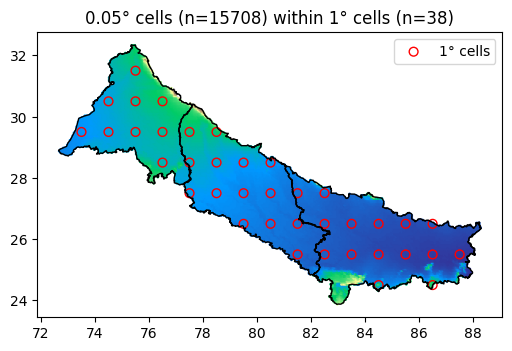

In [2]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 1 — region masks at BOTH resolutions (1° and 0.05°) + elev     ║
# ╚══════════════════════════════════════════════════════════════════════╝

def _read_grid(folder, prefix, yr_lo, yr_hi):
    for yr in range(yr_lo, yr_hi + 1):
        fp = glob.glob(os.path.join(folder, f"*{yr}*.nc"))
        if fp:
            ds = xr.open_dataset(fp[0])
            latn = "lat" if ("lat" in ds.coords or "lat" in ds.dims) else "latitude"
            lonn = "lon" if ("lon" in ds.coords or "lon" in ds.dims) else "longitude"
            la, lo = ds[latn].values, ds[lonn].values
            ds.close()
            if la[0] > la[-1]: la = la[::-1]
            return la, lo, latn, lonn
    raise FileNotFoundError(f"No .nc found in {folder}")

# ---- grids ----
lat1, lon1, LAT1, LON1   = _read_grid(GCM_1DEG_DIR,    "gcm",    TRAIN_START, TRAIN_END)
lat5, lon5, LAT5, LON5   = _read_grid(CHIRPS_005_DIR,  "CHIRPS", TRAIN_START, TRAIN_END)
n1lat, n1lon = len(lat1), len(lon1)
n5lat, n5lon = len(lat5), len(lon5)
print(f"1°    grid: {n1lat} × {n1lon}")
print(f"0.05° grid: {n5lat} × {n5lon}")

# ---- region polygon ----
gdf = gpd.read_file(SHAPEFILE)
gdf = gdf.set_crs(epsg=4326) if gdf.crs is None else gdf.to_crs(epsg=4326)
region = gdf.union_all() if hasattr(gdf, "union_all") else gdf.unary_union

def _mask(la, lo):
    LON, LAT = np.meshgrid(lo, la)
    try:
        from shapely import contains_xy
        m = contains_xy(region, LON.ravel(), LAT.ravel()).reshape(LON.shape)
    except Exception:
        from shapely.vectorized import contains
        m = contains(region, LON.ravel(), LAT.ravel()).reshape(LON.shape)
    return m

# ---- 1° region cells (for QM stage) ----
m1 = _mask(lat1, lon1)
# include any 1° cell that the region touches (buffer) so every 0.05° cell has a parent
if m1.sum() == 0:                       # region smaller than one 1° cell
    LON, LAT = np.meshgrid(lon1, lat1)
    d = (LAT - region.centroid.y)**2 + (LON - region.centroid.x)**2
    m1 = d == d.min()
ii1, jj1 = np.where(m1)
n1 = len(ii1)
print(f"1°    region cells: {n1}")

# ---- 0.05° region cells (MLP target/output) ----
m5 = _mask(lat5, lon5)
assert m5.sum() > 0, "no 0.05° cells inside shapefile"
flat = np.where(m5.ravel())[0]
ii5, jj5 = np.unravel_index(flat, (n5lat, n5lon))
n5 = len(ii5)
print(f"0.05° region cells: {n5}")

# ---- map each 0.05° region cell → its parent 1° cell (containment/nearest) ----
# index into the 1° region-cell list (0..n1-1) for every 0.05° cell
p_lat = np.abs(lat1[:, None] - lat5[ii5][None, :]).argmin(0)   # nearest 1° lat row
p_lon = np.abs(lon1[:, None] - lon5[jj5][None, :]).argmin(0)   # nearest 1° lon col
# convert (row,col) in full 1° grid → position in the masked 1° list
pos1 = {(int(r), int(c)): k for k, (r, c) in enumerate(zip(ii1, jj1))}
parent = np.array([pos1.get((int(p_lat[i]), int(p_lon[i])), -1) for i in range(n5)])
# any 0.05° cell whose nearest 1° cell isn't in the region → attach to closest region cell
if (parent < 0).any():
    bad = np.where(parent < 0)[0]
    for b in bad:
        d = (lat1[ii1] - lat5[ii5[b]])**2 + (lon1[jj1] - lon5[jj5[b]])**2
        parent[b] = int(d.argmin())
print(f"Parent map: every 0.05° cell linked to one of {n1} bias-corrected 1° cells ✔")

# ---- elevation interpolated to 0.05° region cells ----
de = xr.open_dataset(ELEV_FILE)
ela = de["lat"].values if "lat" in de.coords else de["latitude"].values
elo = de["lon"].values if "lon" in de.coords else de["longitude"].values
edata = np.nan_to_num(de["elevation"].values.astype(np.float32), nan=0.0)
de.close()
if ela[0] > ela[-1]: ela = ela[::-1]; edata = edata[::-1, :]
elev_reg = RegularGridInterpolator((ela, elo), edata, method="linear",
                                   bounds_error=False, fill_value=0.0
                                   )(np.column_stack([lat5[ii5], lon5[jj5]])).astype(np.float32)

# ── bounding-box windows (for compact region-masked file saving) ─────
def _window(ii, jj, lat, lon, buf):
    i0, i1 = max(int(ii.min())-buf, 0), min(int(ii.max())+buf, len(lat)-1)
    j0, j1 = max(int(jj.min())-buf, 0), min(int(jj.max())+buf, len(lon)-1)
    return dict(lat=lat[i0:i1+1], lon=lon[j0:j1+1],
                ii=(ii - i0).astype(np.int64), jj=(jj - j0).astype(np.int64))
WIN1 = _window(ii1, jj1, lat1, lon1, 1)   # 1° window (gcm1, chr1)
WIN5 = _window(ii5, jj5, lat5, lon5, 2)   # 0.05° window (chr5)
print(f"Save windows → 1°: {len(WIN1['lat'])}×{len(WIN1['lon'])}  "
      f"0.05°: {len(WIN5['lat'])}×{len(WIN5['lon'])}")

STATIC_COLS = np.column_stack([lat5[ii5], lon5[jj5], elev_reg]).astype(np.float32)
print(f"Static features {STATIC_COLS.shape} [lat, lon, elev] | "
      f"elev {elev_reg.min():.0f}–{elev_reg.max():.0f} m")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(lon5[jj5], lat5[ii5], s=1, c=elev_reg, cmap="terrain")
ax.scatter(lon1[jj1], lat1[ii1], s=40, facecolors="none", edgecolors="red", label="1° cells")
gdf.boundary.plot(ax=ax, color="k", lw=1)
ax.legend(); ax.set_title(f"0.05° cells (n={n5}) within 1° cells (n={n1})"); plt.show()


In [3]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 2 — loaders (1° GCM, 1° CHIRPS, 0.05° CHIRPS) + MLP + helpers  ║
# ╚══════════════════════════════════════════════════════════════════════╝
_CACHE = {}
SAVE_MASKED = True                       # also save region-masked years to disk (.nc)
MASK_DIR    = f"{OUT_DIR}/region_masked" # gcm1_/chr1_/chr5_ regional files live here
os.makedirs(MASK_DIR, exist_ok=True)

# region cells on a compact bounding-box WINDOW, per kind (for masked .nc)
def _kind_grid(kind):
    w = WIN5 if kind == "chr5" else WIN1
    return w["lat"], w["lon"], len(w["lat"]), len(w["lon"]), w["ii"], w["jj"]

def _load_year(kind, yr):
    """kind: 'gcm1','chr1','chr5'  → (data[T, ncells], dates, doys) over region.
    Region-masked years are cached to disk (MASK_DIR) and reused on later runs."""
    key = (kind, yr)
    if key in _CACHE: return _CACHE[key]

    # fast path: read previously-saved region-masked file
    mfp = os.path.join(MASK_DIR, f"{kind}_{yr}.nc")
    if SAVE_MASKED and os.path.exists(mfp):
        d = xr.open_dataset(mfp)
        t = pd.to_datetime(d["time"].values)
        rla, rlo, nrl, nrc, ii, jj = _kind_grid(kind)
        data = d["pr"].values[:, ii, jj].astype(np.float32)
        d.close()
        out = (data, t, t.day_of_year.values.astype(np.int32))
        _CACHE[key] = out; return out

    if   kind == "gcm1": folder, var, ii, jj, latn, lonn = GCM_1DEG_DIR,    GCM_VAR,         ii1, jj1, LAT1, LON1
    elif kind == "chr1": folder, var, ii, jj, latn, lonn = CHIRPS_1DEG_DIR, CHIRPS_1DEG_VAR, ii1, jj1, LAT1, LON1
    elif kind == "chr5": folder, var, ii, jj, latn, lonn = CHIRPS_005_DIR,  CHIRPS_005_VAR,  ii5, jj5, LAT5, LON5
    fp = glob.glob(os.path.join(folder, f"*{yr}*.nc"))
    if not fp:
        _CACHE[key] = None; print(f"  ⚠ missing {kind} {yr}"); return None
    ds = xr.open_dataset(fp[0])
    t  = pd.to_datetime(ds["time"].values)
    la = ds[latn].values; arr = ds[var].values.astype(np.float32)
    ds.close()
    if la[0] > la[-1]: arr = arr[:, ::-1, :]
    if kind.startswith("chr"):
        arr[arr == CHIRPS_FILL] = np.nan; arr[arr < 0] = np.nan
    data = arr[:, ii, jj]
    out = (data, t, t.day_of_year.values.astype(np.int32))
    _CACHE[key] = out

    # save region-masked year as a small regional NetCDF (Panoply-openable)
    if SAVE_MASKED:
        rla, rlo, nrl, nrc, rii, rjj = _kind_grid(kind)
        grid = np.full((len(t), nrl, nrc), np.nan, np.float32)
        grid[:, rii, rjj] = data
        xr.Dataset({"pr": (["time","lat","lon"], grid,
                    {"units":"mm/day","long_name":f"region-masked {kind} {yr}"})},
                   coords={"time": t, "lat": rla, "lon": rlo}
                  ).to_netcdf(mfp, encoding={"pr":{"zlib":True,"complevel":4,"dtype":"float32"}})
    return out

def load_month(kind, years, month):
    D, O, T = [], [], []
    for yr in years:
        r = _load_year(kind, yr)
        if r is None: continue
        data, dates, doys = r
        m = dates.month == month
        if not m.any(): continue
        D.append(data[m]); O.append(doys[m]); T.append(dates[m])
    if not D: return None, None, None
    dates = T[0].append(T[1:]) if len(T) > 1 else T[0]
    return np.concatenate(D), np.concatenate(O), dates

# ── empirical quantile mapping (per cell), used at 1° ────────────────
def qm_fit(obs_2d, mod_2d):
    obs = np.where(np.isnan(obs_2d), np.nanmedian(obs_2d, 0), obs_2d)
    mod = np.where(np.isnan(mod_2d), np.nanmedian(mod_2d, 0), mod_2d)
    return (np.quantile(obs, Q_LEVELS, 0).T.astype(np.float32),
            np.quantile(mod, Q_LEVELS, 0).T.astype(np.float32))

def qm_apply(mod_2d, obs_q, mod_q):
    bc = np.full_like(mod_2d, np.nan)
    for k in range(mod_2d.shape[1]):
        v = mod_2d[:, k]; nm = np.isnan(v)
        if np.any(~nm) and not np.isnan(mod_q[k, 0]):
            _, uid = np.unique(mod_q[k], return_index=True)
            bc[~nm, k] = np.clip(np.interp(v[~nm], mod_q[k, uid], obs_q[k, uid]), 0, None)
    return bc

# ── feature builder for the 0.05° MLP (6 features) ───────────────────
def build_X(bc_gcm_at005, doys):
    """bc_gcm_at005: (n_days, n5) bias-corrected 1° GCM broadcast to 0.05° cells."""
    nd = len(doys)
    sin_d = np.sin(2*np.pi*doys/365.25).astype(np.float32)
    cos_d = np.cos(2*np.pi*doys/365.25).astype(np.float32)
    X = np.empty((nd*n5, N_FEATURES), np.float32)
    X[:, 0] = bc_gcm_at005.ravel()
    X[:, 1] = np.tile(STATIC_COLS[:, 0], nd)
    X[:, 2] = np.tile(STATIC_COLS[:, 1], nd)
    X[:, 3] = np.tile(STATIC_COLS[:, 2], nd)
    X[:, 4] = np.repeat(sin_d, n5)
    X[:, 5] = np.repeat(cos_d, n5)
    return X

def bc1_to_005(bc_gcm_1deg_days):
    """(n_days, n1) bias-corrected 1° GCM  →  (n_days, n5) via parent map."""
    return bc_gcm_1deg_days[:, parent]

# ── configurable MLP ─────────────────────────────────────────────────
class MLPNet(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        act_map = {"gelu": nn.GELU, "leaky_relu": nn.LeakyReLU, "relu": nn.ReLU}
        act = act_map.get(cfg.get("activation", "relu"), nn.ReLU)
        layers, prev = [], N_FEATURES
        for h in cfg["hidden"]:
            layers.append(nn.Linear(prev, h))
            if cfg.get("batchnorm", True): layers.append(nn.BatchNorm1d(h))
            layers += [act(), nn.Dropout(cfg.get("dropout", 0.2))]; prev = h
        layers += [nn.Linear(prev, 1), nn.Softplus()]
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x).squeeze(1)

DEFAULT_CFG = {"hidden": [128, 128, 64, 64], "dropout": 0.15, "lr": 3e-4,
               "weight_decay": 1e-6, "batch_size": 32768, "activation": "leaky_relu",
               "batchnorm": False, "log_transform": False, "epochs": EPOCHS}

def load_cfg():
    if os.path.exists(BEST_PARAMS):
        c = json.load(open(BEST_PARAMS)); c.setdefault("epochs", EPOCHS)
        print(f"✅ tuned cfg: {c['hidden']} lr={c['lr']:.2e} drop={c['dropout']:.2f} log={c['log_transform']}")
        return c
    print("⚠ no optuna json — using DEFAULT_CFG"); return dict(DEFAULT_CFG)

def _predict_mm(model, X_sc, log, bs):
    model.eval(); out = []
    with torch.no_grad():
        for i in range(0, len(X_sc), bs):
            xb = torch.from_numpy(X_sc[i:i+bs]).to(DEVICE, non_blocking=True)
            with torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
                out.append(model(xb).float().cpu().numpy())
    p = np.concatenate(out)
    return np.clip(np.expm1(p) if log else p, 0, None)

def _rmse_mm(model, X_sc, y, log, bs):
    return float(np.sqrt(mean_squared_error(y, _predict_mm(model, X_sc, log, bs))))

def train_model(cfg, Xtr, ytr, Xval=None, yval=None, trial=None, epochs=None,
                patience=15, min_epochs=0, verbose=False, tag="", log_csv=None):
    """Trains an MLP. Early stopping is ALLOWED only after `min_epochs`.
    If verbose: prints every epoch. If log_csv: appends every epoch to that CSV."""
    import optuna, csv
    epochs = epochs or cfg.get("epochs", EPOCHS)
    log, bs = cfg.get("log_transform", False), cfg["batch_size"]
    model = MLPNet(cfg).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=cfg["lr"], weight_decay=cfg.get("weight_decay", 0.0))
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    crit = nn.MSELoss(); gs = torch.cuda.amp.GradScaler(enabled=USE_AMP)
    y_in = np.log1p(ytr).astype(np.float32) if log else ytr.astype(np.float32)
    loader = DataLoader(TensorDataset(torch.from_numpy(Xtr), torch.from_numpy(y_in)),
                        batch_size=bs, shuffle=True, drop_last=True,
                        pin_memory=USE_AMP, num_workers=2 if USE_AMP else 0,
                        persistent_workers=USE_AMP)
    if log_csv:
        cf = open(log_csv, "w", newline=""); cw = csv.writer(cf)
        cw.writerow(["epoch", "train_loss", "val_rmse", "best_val_rmse", "bad_epochs", "lr"])
    best, best_state, bad, best_ep = np.inf, None, 0, 0
    hist = {"train_loss": [], "val_rmse": []}
    for ep in range(1, epochs + 1):
        model.train(); run = 0.0
        for Xb, yb in loader:
            Xb = Xb.to(DEVICE, non_blocking=True); yb = yb.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
                loss = crit(model(Xb), yb)
            gs.scale(loss).backward(); gs.step(opt); gs.update(); run += loss.item()
        cur_lr = opt.param_groups[0]["lr"]; sched.step()
        tl = run / max(1, len(loader)); hist["train_loss"].append(tl)
        if Xval is not None:
            vr = _rmse_mm(model, Xval, yval, log, bs); hist["val_rmse"].append(vr)
            if trial is not None:
                trial.report(vr, ep)
                if trial.should_prune():
                    if log_csv: cf.close()
                    raise optuna.TrialPruned()
            if vr < best - 1e-4:
                best, bad, best_ep = vr, 0, ep
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            else:
                bad += 1
            if verbose:
                print(f"    {tag} ep{ep:>3} | loss={tl:.4f} | val_rmse={vr:.4f} | "
                      f"best={best:.4f}@{best_ep} | bad={bad}", flush=True)
            if log_csv:
                cw.writerow([ep, f"{tl:.6f}", f"{vr:.6f}", f"{best:.6f}", bad, f"{cur_lr:.2e}"]); cf.flush()
            # early stop ONLY after the guaranteed minimum number of epochs
            if ep >= min_epochs and bad >= patience:
                if verbose: print(f"    {tag} early-stop at ep{ep} (min_epochs={min_epochs})", flush=True)
                break
        else:
            if verbose: print(f"    {tag} ep{ep:>3} | loss={tl:.4f}", flush=True)
            if log_csv: cw.writerow([ep, f"{tl:.6f}", "", "", "", f"{cur_lr:.2e}"]); cf.flush()
    if log_csv: cf.close()
    if best_state is not None: model.load_state_dict(best_state)
    return model, (best if np.isfinite(best) else hist["train_loss"][-1]), hist

# sanity check
print("✅ Helpers ready. Sanity — July 1990:")
_g1,_,_ = load_month("gcm1", [1990], 7)
_c1,_,_ = load_month("chr1", [1990], 7)
_c5,_,_ = load_month("chr5", [1990], 7)
print(f"   1° GCM   : {_g1.shape}   1° CHIRPS: {_c1.shape}   0.05° CHIRPS: {_c5.shape}")
print(f"   parent map → bc1_to_005 makes {_g1.shape} into (days, {n5})")


✅ Helpers ready. Sanity — July 1990:
   1° GCM   : (31, 38)   1° CHIRPS: (31, 38)   0.05° CHIRPS: (31, 15708)
   parent map → bc1_to_005 makes (31, 38) into (days, 15708)


In [4]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 3 — STAGE 1: bias-correct 1° GCM against 1° CHIRPS (per month) ║
# ║  QM fit on TRAIN cell-to-cell; applied to train + test 1° GCM.       ║
# ╚══════════════════════════════════════════════════════════════════════╝
qm1 = {}
if os.path.exists(QM1_TF_PATH):
    with np.load(QM1_TF_PATH) as z: qm1 = {k: z[k] for k in z.files}
    print(f"Loaded existing 1° QM for {len(qm1)//2} month(s)")

print("Fitting 1° QM transfer functions (per calendar month)…")
for month in range(1, 13):
    mk = f"m{month:02d}"
    if f"{mk}_obs_q" in qm1: 
        print(f"  {MONTH_NAMES[month-1]} ✓ (cached)"); continue
    g1, _, _ = load_month("gcm1", range(TRAIN_START, TRAIN_END+1), month)
    c1, _, _ = load_month("chr1", range(TRAIN_START, TRAIN_END+1), month)
    n = min(len(g1), len(c1)); g1, c1 = g1[:n], c1[:n]
    obs_q, mod_q = qm_fit(c1, g1)
    qm1[f"{mk}_obs_q"] = obs_q; qm1[f"{mk}_his_q"] = mod_q
    np.savez_compressed(QM1_TF_PATH, **qm1)
    print(f"  {MONTH_NAMES[month-1]} ✓  (1° cells={g1.shape[1]})", flush=True)

def make_bc1(years, out_nc, label):
    """apply 1° QM to the 1° GCM for the given years → save bias-corrected 1° NetCDF"""
    maps, times = [], []
    for month in range(1, 13):
        mk = f"m{month:02d}"
        g1, doy, dates = load_month("gcm1", years, month)
        if g1 is None: continue
        bc = qm_apply(g1, qm1[f"{mk}_obs_q"], qm1[f"{mk}_his_q"])   # (days, n1)
        for di, dt in enumerate(dates):
            grid = np.full((n1lat, n1lon), np.nan, np.float32)
            grid[ii1, jj1] = bc[di]; maps.append(grid); times.append(pd.Timestamp(dt))
    arr = np.stack(maps); t = pd.to_datetime(times)
    idx = np.argsort(t); arr, t = arr[idx], t[idx]
    xr.Dataset({"pr": (["time","lat","lon"], arr,
                {"units":"mm/day","long_name":f"bias-corrected 1° GCM {label}"})},
               coords={"time": t, "lat": lat1, "lon": lon1}
              ).to_netcdf(out_nc, encoding={"pr":{"zlib":True,"complevel":4,"dtype":"float32"}})
    print(f"✅ {label}: {arr.shape} → {out_nc} ({os.path.getsize(out_nc)/1e6:.1f} MB)", flush=True)

print("\nApplying 1° QM to produce bias-corrected 1° GCM:")
make_bc1(range(TRAIN_START, TRAIN_END+1), BC1_TRAIN_NC, "train")
make_bc1(range(TEST_START,  TEST_END +1), BC1_TEST_NC,  "test")
print("\n✅ STAGE 1 complete — bias-corrected 1° GCM saved.")


Fitting 1° QM transfer functions (per calendar month)…
  Jan ✓  (1° cells=38)
  Feb ✓  (1° cells=38)
  Mar ✓  (1° cells=38)
  Apr ✓  (1° cells=38)
  May ✓  (1° cells=38)
  Jun ✓  (1° cells=38)
  Jul ✓  (1° cells=38)
  Aug ✓  (1° cells=38)
  Sep ✓  (1° cells=38)
  Oct ✓  (1° cells=38)
  Nov ✓  (1° cells=38)
  Dec ✓  (1° cells=38)

Applying 1° QM to produce bias-corrected 1° GCM:
✅ train: (8766, 12, 19) → /kaggle/working/region_bcsd_output/bc_gcm_1deg_train.nc (0.7 MB)
✅ test: (3652, 12, 19) → /kaggle/working/region_bcsd_output/bc_gcm_1deg_test.nc (0.3 MB)

✅ STAGE 1 complete — bias-corrected 1° GCM saved.


In [5]:
# # ╔══════════════════════════════════════════════════════════════════════╗
# # ║  Cell 3.5 — OPTUNA: tune the downscaling MLP (BC-1°-GCM → 0.05°)     ║
# # ║  Tunes on 2 months (Jul + Jan), year-based val split, RESUMABLE.     ║
# # ║  Saves: optuna_study.db · optuna_best_params.json · trials CSV       ║
# # ╚══════════════════════════════════════════════════════════════════════╝
# import optuna, shutil
# from optuna.samplers import TPESampler
# from optuna.pruners  import MedianPruner

# TUNE_MONTHS = [7, 1]      # monsoon + dry
# N_TRIALS    = 12
# TUNE_EPOCHS = 30
# VAL_YEARS   = 4           # 2001–2004 as validation
# TUNE_FRAC   = 1.00        # region is small → use all cells

# # resume an earlier search if its db was kept
# if os.path.exists(OPTUNA_DB):
#     print("Found existing optuna_study.db — will continue that search.")

# # ── build tuning data once: bias-corrected 1° GCM (→0.05°) vs 0.05° CHIRPS
# cut = TRAIN_END - VAL_YEARS
# month_data = {}
# for m in TUNE_MONTHS:
#     g1, doy, dates = load_month("gcm1", range(TRAIN_START, TRAIN_END+1), m)
#     bc1 = qm_apply(g1, qm1[f"m{m:02d}_obs_q"], qm1[f"m{m:02d}_his_q"])   # (days, n1)
#     bc005 = bc1_to_005(bc1)                                             # (days, n5)
#     y5, _, _ = load_month("chr5", range(TRAIN_START, TRAIN_END+1), m)
#     n = min(len(bc005), len(y5)); bc005, y5, doy, dates = bc005[:n], y5[:n], doy[:n], dates[:n]
#     X = build_X(bc005, doy); y = y5.reshape(-1)
#     yr = np.repeat(dates.year.values, n5)
#     fin = np.isfinite(X).all(1) & np.isfinite(y) & (y >= 0)
#     tr, va = fin & (yr <= cut), fin & (yr > cut)
#     sc = StandardScaler().fit(X[tr])
#     month_data[m] = dict(Xtr=sc.transform(X[tr]).astype(np.float32), ytr=y[tr],
#                          Xva=sc.transform(X[va]).astype(np.float32), yva=y[va],
#                          ystd=float(np.nanstd(y[va])))
#     print(f"{MONTH_NAMES[m-1]}: train={int(tr.sum()):,} val={int(va.sum()):,} "
#           f"obs std={month_data[m]['ystd']:.2f}")
#     del X, y

# def objective(trial):
#     n_layers = trial.suggest_int("n_layers", 2, 4)
#     hidden, prev = [], 512
#     for i in range(n_layers):                                  # funnel only
#         ch = [c for c in [512, 256, 128, 64] if c <= prev]
#         h = trial.suggest_categorical(f"u{i}_{prev}", ch); hidden.append(h); prev = h
#     cfg = {"hidden": hidden,
#            "dropout": trial.suggest_float("dropout", 0.0, 0.4),
#            "lr": trial.suggest_float("lr", 1e-4, 5e-3, log=True),
#            "weight_decay": trial.suggest_float("weight_decay", 1e-8, 1e-3, log=True),
#            "batch_size": trial.suggest_categorical("batch_size", [16384,32768,65536,131072]),
#            "activation": trial.suggest_categorical("activation", ["relu","gelu","leaky_relu"]),
#            "batchnorm": trial.suggest_categorical("batchnorm", [True, False]),
#            "log_transform": trial.suggest_categorical("log_transform", [True, False])}
#     score = 0.0
#     for k, m in enumerate(TUNE_MONTHS):
#         d = month_data[m]
#         _, rmse, _ = train_model(cfg, d["Xtr"], d["ytr"], d["Xva"], d["yva"],
#                                  trial=trial if k == 0 else None,
#                                  epochs=TUNE_EPOCHS, patience=8)
#         trial.set_user_attr(f"rmse_{MONTH_NAMES[m-1]}", float(rmse))
#         score += (rmse / d["ystd"]) / len(TUNE_MONTHS)
#     return score

# study = optuna.create_study(direction="minimize", study_name="region_bcsd",
#                             sampler=TPESampler(seed=SEED),
#                             pruner=MedianPruner(n_warmup_steps=6),
#                             storage=f"sqlite:///{OPTUNA_DB}", load_if_exists=True)
# done = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
# print(f"Trials complete: {done} | running {max(N_TRIALS-done,0)} more")
# if N_TRIALS - done > 0:
#     study.optimize(objective, n_trials=N_TRIALS - done, show_progress_bar=True)

# print(f"\nBest combined score: {study.best_value:.4f}")
# print(f"  Jul RMSE: {study.best_trial.user_attrs.get('rmse_Jul'):.3f} | "
#       f"Jan RMSE: {study.best_trial.user_attrs.get('rmse_Jan'):.3f}")
# for k, v in study.best_params.items(): print(f"   {k:<16}: {v}")

# # ── save best config + full history (resumable + thesis record) ──────
# # bp = study.best_params; hidden, prev = [], 512
# for i in range(bp["n_layers"]): hidden.append(bp[f"u{i}_{prev}"]); prev = hidden[-1]
# BEST = {"hidden": hidden, "dropout": float(bp["dropout"]), "lr": float(bp["lr"]),
#         "weight_decay": float(bp["weight_decay"]), "batch_size": int(bp["batch_size"]),
#         "activation": bp["activation"], "batchnorm": bool(bp["batchnorm"]),
#         "log_transform": bool(bp["log_transform"]), "epochs": EPOCHS,
#         "tuned_on_months": TUNE_MONTHS, "best_score": float(study.best_value)}
# json.dump(BEST, open(BEST_PARAMS, "w"), indent=2)
# rows = []
# for t in study.trials:
#     r = {"trial": t.number, "state": str(t.state), "value": t.value}
#     r.update(t.params); r.update(t.user_attrs); rows.append(r)
# pd.DataFrame(rows).to_csv(f"{OUT_DIR}/optuna_trials_full.csv", index=False)
# print(f"\n✅ Saved: {BEST_PARAMS}")
# print(f"✅ Saved: {OUT_DIR}/optuna_trials_full.csv")
# print(f"✅ Saved: {OPTUNA_DB}  (re-run this cell to resume if interrupted)")
# try:
#     from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances
#     plot_optimization_history(study).figure.savefig(f"{OUT_DIR}/optuna_history.png", dpi=150, bbox_inches="tight")
#     plot_param_importances(study).figure.savefig(f"{OUT_DIR}/optuna_importance.png", dpi=150, bbox_inches="tight")
#     plt.show()
# except Exception as e:
#     print("plot skipped:", e)
# for m in TUNE_MONTHS: month_data[m].clear()


In [6]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 3.6 — Hardcoded best parameters (Optuna not used)             ║
# ╚══════════════════════════════════════════════════════════════════════╝

cfg = {
    "hidden": [256, 64, 64],          # n_layers=3 | u0_512=256, u1_256=64, u2_64=64
    "dropout": 0.0353970008207678,
    "lr": 0.000215262809722153,
    "weight_decay": 1.6832027985721884e-08,
    "batch_size": 131072,
    "activation": "leaky_relu",
    "batchnorm": False,
    "log_transform": False,
    "epochs": EPOCHS,
}

json.dump(cfg, open(BEST_PARAMS, "w"), indent=2)

print(json.dumps(cfg, indent=2))
print("\nSaved hardcoded best parameters (Optuna not used).")


{
  "hidden": [
    256,
    64,
    64
  ],
  "dropout": 0.0353970008207678,
  "lr": 0.000215262809722153,
  "weight_decay": 1.6832027985721884e-08,
  "batch_size": 131072,
  "activation": "leaky_relu",
  "batchnorm": false,
  "log_transform": false,
  "epochs": 300
}

Saved hardcoded best parameters (Optuna not used).


In [7]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 4 — STAGE 2: MLP downscaling  (logs epoch, loss, RMSE, R²)     ║
# ║  Min 100 epochs, then patience-15 early stopping.                    ║
# ╚══════════════════════════════════════════════════════════════════════╝
CFG = load_cfg()
LOG, BS = CFG["log_transform"], CFG["batch_size"]
VAL_YEARS_FIN, PATIENCE, MIN_EPOCHS = 3, 15, 20
cut = TRAIN_END - VAL_YEARS_FIN
print(f"cfg: hidden={CFG['hidden']} lr={CFG['lr']:.2e} drop={CFG['dropout']:.2f} "
      f"bn={CFG['batchnorm']} act={CFG['activation']} log={LOG}")

def bc1_gcm_at005(years, month):
    g1, doy, dates = load_month("gcm1", years, month)
    if g1 is None: return None, None, None
    mk = f"m{month:02d}"
    bc1 = qm_apply(g1, qm1[f"{mk}_obs_q"], qm1[f"{mk}_his_q"])
    return bc1_to_005(bc1), doy, dates

def _metrics_mm(model, X_sc, y, log, bs):
    p = _predict_mm(model, X_sc, log, bs)
    return float(np.sqrt(mean_squared_error(y, p))), float(r2_score(y, p))

# ── trainer with epoch | loss | val_rmse | val_R² logging ────────────
def train_verbose(cfg, Xtr, ytr, Xval, yval, tag, ep_csv,
                  epochs=100, patience=15, min_epochs=100):
    import csv
    log, bs = cfg.get("log_transform", False), cfg["batch_size"]
    model = MLPNet(cfg).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=cfg["lr"],
                           weight_decay=cfg.get("weight_decay", 0.0))
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    crit = nn.MSELoss(); gs = torch.cuda.amp.GradScaler(enabled=USE_AMP)
    y_in = (np.log1p(ytr) if log else ytr).astype(np.float32)
    loader = DataLoader(TensorDataset(torch.from_numpy(Xtr), torch.from_numpy(y_in)),
                        batch_size=bs, shuffle=True, drop_last=True,
                        pin_memory=USE_AMP, num_workers=2 if USE_AMP else 0,
                        persistent_workers=USE_AMP)
    cf = open(ep_csv, "w", newline=""); cw = csv.writer(cf)
    cw.writerow(["epoch", "loss", "val_rmse", "val_r2"])
    best, best_state, bad = np.inf, None, 0
    hist = {"loss": [], "val_rmse": [], "val_r2": []}
    for ep in range(1, epochs + 1):
        model.train(); run = 0.0
        for Xb, yb in loader:
            Xb = Xb.to(DEVICE, non_blocking=True); yb = yb.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
                loss = crit(model(Xb), yb)
            gs.scale(loss).backward(); gs.step(opt); gs.update(); run += loss.item()
        sched.step()
        tl = run / max(1, len(loader))
        vr, vr2 = _metrics_mm(model, Xval, yval, log, bs)
        hist["loss"].append(tl); hist["val_rmse"].append(vr); hist["val_r2"].append(vr2)
        print(f"    {tag} epoch {ep:>3} | loss={tl:.4f} | RMSE={vr:.4f} | R²={vr2:.4f}", flush=True)
        cw.writerow([ep, f"{tl:.6f}", f"{vr:.6f}", f"{vr2:.6f}"]); cf.flush()
        if vr < best - 1e-4:
            best, bad = vr, 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
        if ep >= min_epochs and bad >= patience:
            print(f"    {tag} early-stop at epoch {ep}", flush=True); break
    cf.close()
    if best_state is not None: model.load_state_dict(best_state)
    return model, best, hist

summary, epoch_metrics = {}, {}
print("\n" + "="*58 + "\n  STAGE 2 — 12 monthly downscaling MLPs\n" + "="*58)
for month in range(1, 13):
    mk = f"m{month:02d}"; mp = os.path.join(MODEL_DIR, f"mlp_{mk}.pth")
    if os.path.exists(mp):
        print(f"  ✓ {MONTH_NAMES[month-1]} already trained — loading for metrics", flush=True)
        model = MLPNet(CFG).to(DEVICE)
        model.load_state_dict(torch.load(mp, map_location=DEVICE)); model.eval()
        sc = joblib.load(os.path.join(SCALER_DIR, f"scaler_{mk}.joblib"))
        bc005, doy, dates = bc1_gcm_at005(range(TRAIN_START, TRAIN_END+1), month)
        y5, _, _ = load_month("chr5", range(TRAIN_START, TRAIN_END+1), month)
        if bc005 is not None and y5 is not None:
            n = min(len(bc005), len(y5)); bc005t, y5t, doyt = bc005[:n], y5[:n], doy[:n]
            X = build_X(bc005t, doyt); y = y5t.reshape(-1)
            fin = np.isfinite(X).all(1) & np.isfinite(y) & (y >= 0)
            p_tr = _predict_mm(model, sc.transform(X[fin]).astype(np.float32), LOG, BS)
            rmse_tr = float(np.sqrt(mean_squared_error(y[fin], p_tr)))
            r2_tr   = float(r2_score(y[fin], p_tr))
            bc_te, doy_te, _ = bc1_gcm_at005(range(TEST_START, TEST_END+1), month)
            y_te, _, _       = load_month("chr5", range(TEST_START, TEST_END+1), month)
            rmse_te = r2_te = np.nan
            if bc_te is not None and y_te is not None:
                nt = min(len(bc_te), len(y_te))
                Xte = build_X(bc_te[:nt], doy_te[:nt]); yte = y_te[:nt].reshape(-1)
                vt = np.isfinite(Xte).all(1) & np.isfinite(yte) & (yte >= 0)
                pte = _predict_mm(model, sc.transform(Xte[vt]).astype(np.float32), LOG, BS)
                rmse_te = float(np.sqrt(mean_squared_error(yte[vt], pte)))
                r2_te   = float(r2_score(yte[vt], pte))
            summary[month] = (rmse_tr, r2_tr, rmse_te, r2_te)
            print(f"  TR RMSE={rmse_tr:.3f} R²={r2_tr:.3f} | TE RMSE={rmse_te:.3f} R²={r2_te:.3f}", flush=True)
        del model, sc
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        continue
    print(f"\n── [{month:02d}/12] {MONTH_NAMES[month-1]} {pd.Timestamp.now():%H:%M:%S} ──", flush=True)

    bc005, doy, dates = bc1_gcm_at005(range(TRAIN_START, TRAIN_END+1), month)
    y5, _, _          = load_month("chr5", range(TRAIN_START, TRAIN_END+1), month)
    n = min(len(bc005), len(y5)); bc005, y5, doy, dates = bc005[:n], y5[:n], doy[:n], dates[:n]

    X = build_X(bc005, doy); y = y5.reshape(-1)
    yr = np.repeat(dates.year.values, n5)
    fin = np.isfinite(X).all(1) & np.isfinite(y) & (y >= 0)
    fitm, valm = fin & (yr <= cut), fin & (yr > cut)
    print(f"  fit={int(fitm.sum()):,}  val={int(valm.sum()):,}", flush=True)

    scaler = StandardScaler().fit(X[fitm])
    joblib.dump(scaler, os.path.join(SCALER_DIR, f"scaler_{mk}.joblib"))
    Xf = scaler.transform(X[fitm]).astype(np.float32)
    Xv = scaler.transform(X[valm]).astype(np.float32)

    ep_csv = os.path.join(OUT_DIR, f"epoch_{mk}.csv")
    model, bval, hist = train_verbose(CFG, Xf, y[fitm], Xv, y[valm],
                                      tag=MONTH_NAMES[month-1], ep_csv=ep_csv,
                                      epochs=100, patience=PATIENCE, min_epochs=MIN_EPOCHS)
    torch.save(model.state_dict(), mp); epoch_metrics[month] = hist
    print(f"  best val RMSE={bval:.4f}  (per-epoch log → {os.path.basename(ep_csv)})", flush=True)

    p_tr = _predict_mm(model, scaler.transform(X[fin]).astype(np.float32), LOG, BS)
    rmse_tr = float(np.sqrt(mean_squared_error(y[fin], p_tr))); r2_tr = float(r2_score(y[fin], p_tr))
    bc_te, doy_te, _ = bc1_gcm_at005(range(TEST_START, TEST_END+1), month)
    y_te, _, _       = load_month("chr5", range(TEST_START, TEST_END+1), month)
    rmse_te = r2_te = np.nan
    if bc_te is not None and y_te is not None:
        nt = min(len(bc_te), len(y_te)); Xte = build_X(bc_te[:nt], doy_te[:nt]); yte = y_te[:nt].reshape(-1)
        vt = np.isfinite(Xte).all(1) & np.isfinite(yte) & (yte >= 0)
        pte = _predict_mm(model, scaler.transform(Xte[vt]).astype(np.float32), LOG, BS)
        rmse_te = float(np.sqrt(mean_squared_error(yte[vt], pte))); r2_te = float(r2_score(yte[vt], pte))
    summary[month] = (rmse_tr, r2_tr, rmse_te, r2_te)
    print(f"  TR RMSE={rmse_tr:.3f} R²={r2_tr:.3f} | TE RMSE={rmse_te:.3f} R²={r2_te:.3f}", flush=True)
    del X, y, Xf, Xv
    if torch.cuda.is_available(): torch.cuda.empty_cache()

print("\n  Month  TR_RMSE  TR_R²  TE_RMSE  TE_R²")
for m in range(1, 13):
    if m in summary:
        a,b,c,d = summary[m]; print(f"  {MONTH_NAMES[m-1]:<5}{a:8.3f}{b:7.3f}{c:9.3f}{d:7.3f}")

# ── produce final downscaled 0.05° NetCDFs (compact WIN5 window) ─────
def downscale_period(years, out_nc, label):
    maps, times = [], []
    for month in range(1, 13):
        mk = f"m{month:02d}"; mp = os.path.join(MODEL_DIR, f"mlp_{mk}.pth")
        if not os.path.exists(mp): continue
        model = MLPNet(CFG).to(DEVICE); model.load_state_dict(torch.load(mp, map_location=DEVICE)); model.eval()
        sc = joblib.load(os.path.join(SCALER_DIR, f"scaler_{mk}.joblib"))
        bc005, doy, dates = bc1_gcm_at005(years, month)
        if bc005 is None: continue
        p = _predict_mm(model, sc.transform(build_X(bc005, doy)).astype(np.float32), LOG, BS).reshape(len(doy), n5)
        wl, wo, wii, wjj = WIN5["lat"], WIN5["lon"], WIN5["ii"], WIN5["jj"]
        for di, dt in enumerate(dates):
            grid = np.full((len(wl), len(wo)), np.nan, np.float32); grid[wii, wjj] = p[di]
            maps.append(grid); times.append(pd.Timestamp(dt))
        del model, sc
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        print(f"  {MONTH_NAMES[month-1]} ✓", end="  ", flush=True)
    print()
    arr = np.stack(maps); t = pd.to_datetime(times); idx = np.argsort(t); arr, t = arr[idx], t[idx]
    xr.Dataset({"pr": (["time","lat","lon"], arr,
                {"units":"mm/day","long_name":f"downscaled 0.05° (BC-then-MLP) {label}"})},
               coords={"time": t, "lat": WIN5["lat"], "lon": WIN5["lon"]}
              ).to_netcdf(out_nc, encoding={"pr":{"zlib":True,"complevel":4,"dtype":"float32"}})
    print(f"✅ {label}: {arr.shape} → {out_nc} ({os.path.getsize(out_nc)/1e6:.1f} MB)", flush=True)

print("\nProducing final 0.05° downscaled output:")
downscale_period(range(TRAIN_START, TRAIN_END+1), MLP_TRAIN_NC, "train")
downscale_period(range(TEST_START,  TEST_END +1), MLP_TEST_NC,  "test")
print("\n✅ STAGE 2 complete.")

✅ tuned cfg: [256, 64, 64] lr=2.15e-04 drop=0.04 log=False
cfg: hidden=[256, 64, 64] lr=2.15e-04 drop=0.04 bn=False act=leaky_relu log=False

  STAGE 2 — 12 monthly downscaling MLPs

── [01/12] Jan 00:50:26 ──
  fit=10,225,908  val=1,460,844
    Jan epoch   1 | loss=8.9351 | RMSE=3.0396 | R²=-0.0024
    Jan epoch   2 | loss=8.8574 | RMSE=3.0429 | R²=-0.0045
    Jan epoch   3 | loss=8.8257 | RMSE=3.0444 | R²=-0.0055
    Jan epoch   4 | loss=8.8066 | RMSE=3.0492 | R²=-0.0087
    Jan epoch   5 | loss=8.7918 | RMSE=3.0572 | R²=-0.0140
    Jan epoch   6 | loss=8.7790 | RMSE=3.0625 | R²=-0.0175
    Jan epoch   7 | loss=8.7686 | RMSE=3.0615 | R²=-0.0168
    Jan epoch   8 | loss=8.7575 | RMSE=3.0658 | R²=-0.0197
    Jan epoch   9 | loss=8.7474 | RMSE=3.0683 | R²=-0.0214
    Jan epoch  10 | loss=8.7406 | RMSE=3.0679 | R²=-0.0211
    Jan epoch  11 | loss=8.7318 | RMSE=3.0725 | R²=-0.0241
    Jan epoch  12 | loss=8.7234 | RMSE=3.0687 | R²=-0.0217
    Jan epoch  13 | loss=8.7158 | RMSE=3.0691 | R²


  EVALUATION

  Training (1981-2004)
  ────────────────────────────────────────────
  N (pooled)        = 137,696,328
  MAE  (pooled)     = 3.3124 mm/day
  RMSE (pooled)     = 7.8688 mm/day
  RMSE (cell-mean)  = 5.6666 mm/day   ← honest spatial skill
  R²   (pooled)     = 0.1644
  KGE  (pooled)     = 0.1602

  Testing  (2005-2014)
  ────────────────────────────────────────────
  N (pooled)        = 57,365,616
  MAE  (pooled)     = 3.3924 mm/day
  RMSE (pooled)     = 7.9436 mm/day
  RMSE (cell-mean)  = 5.7641 mm/day   ← honest spatial skill
  R²   (pooled)     = 0.1602
  KGE  (pooled)     = 0.1513


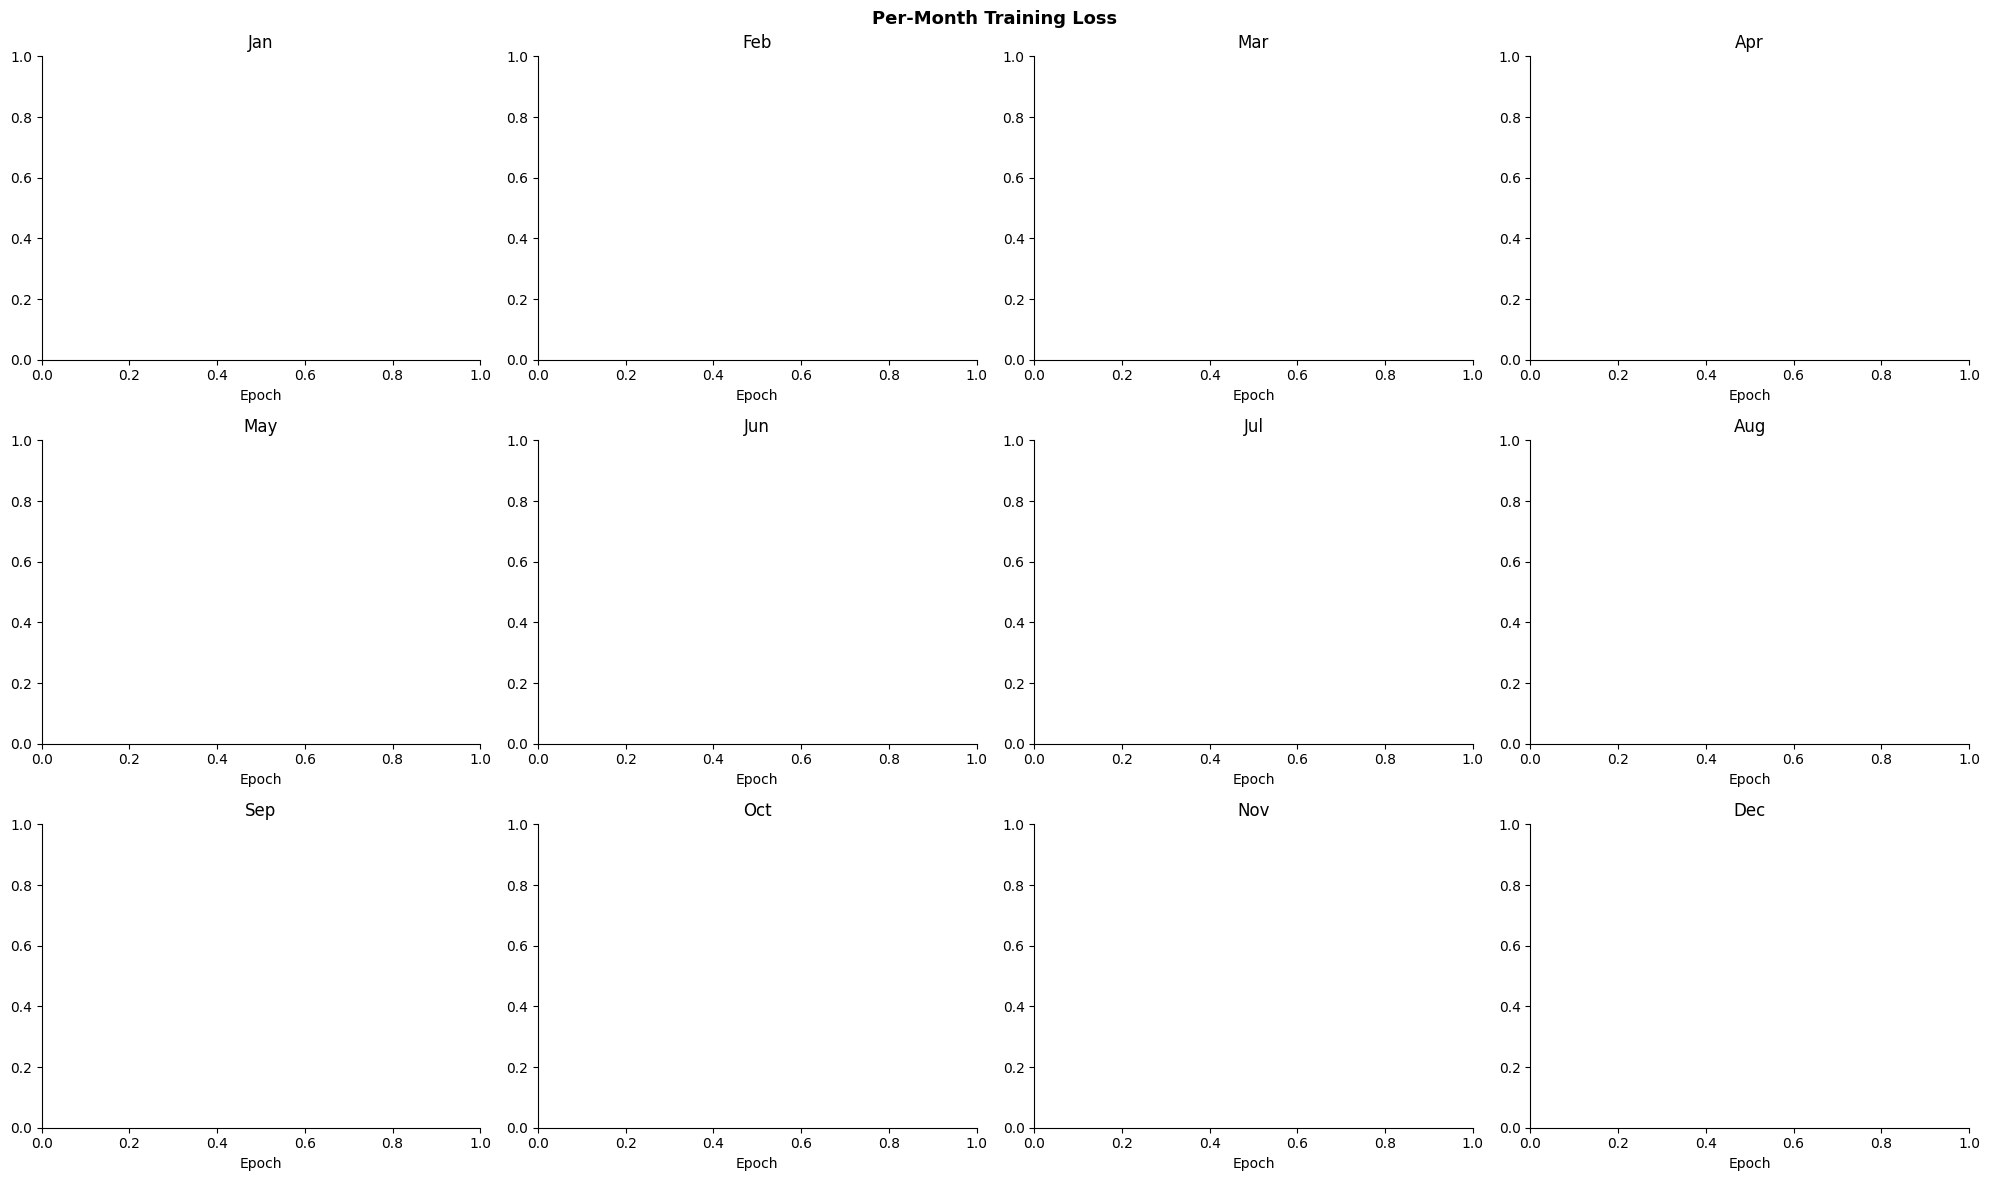

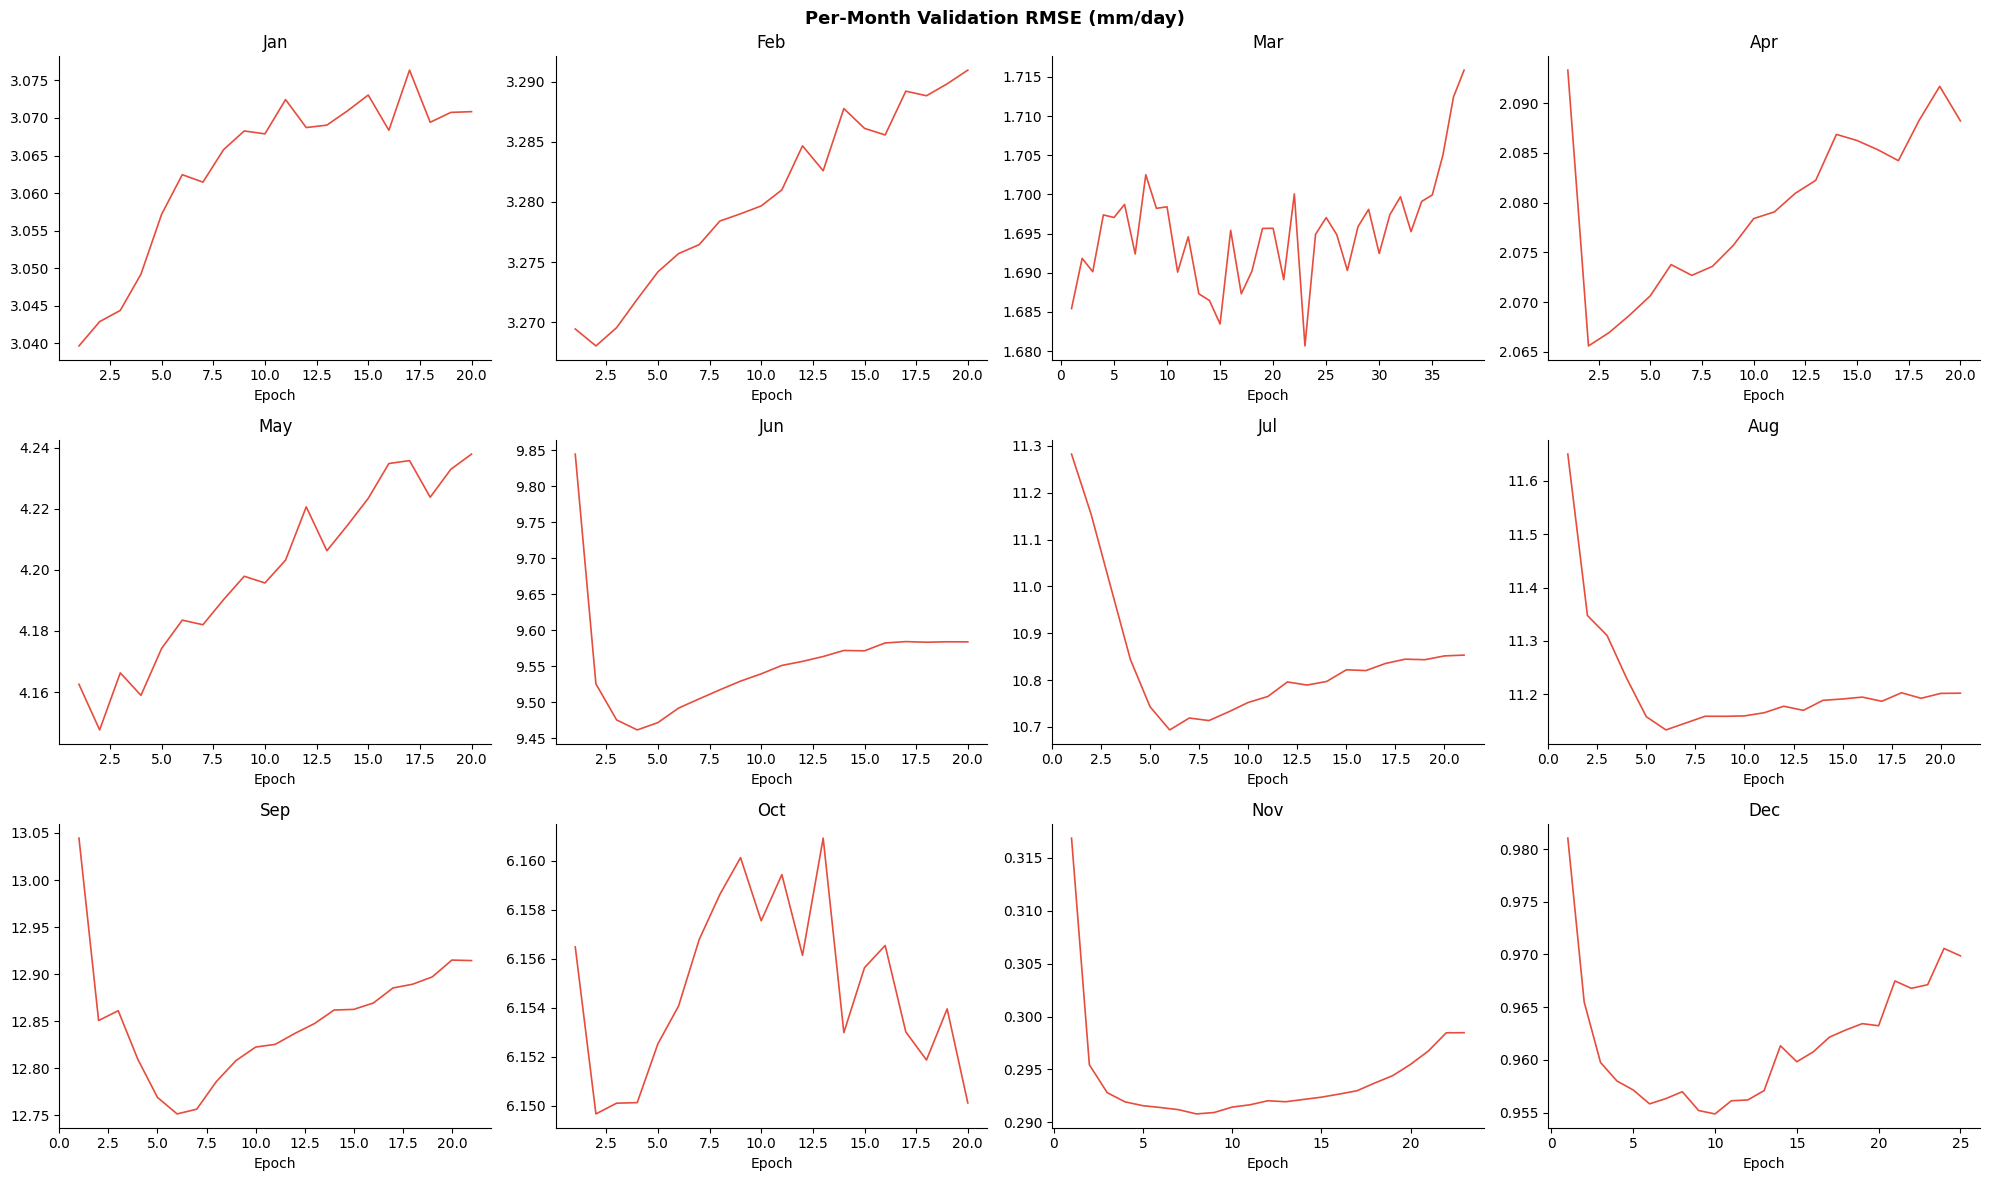

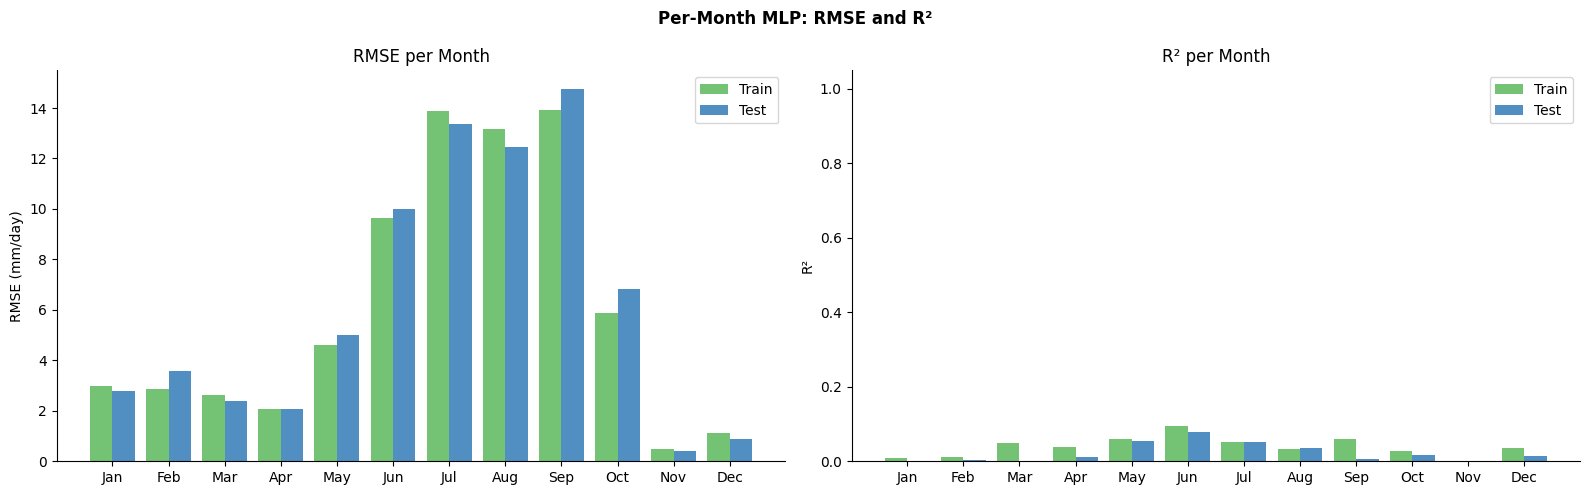


  COMPLETE → /kaggle/working/region_bcsd_output
Finished : 2026-06-19 04:59:50.298397


In [8]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell — QUICK EVALUATION (pooled metrics + training curves + bars)    ║
# ║  Pooled MAE, RMSE, R², KGE on MLP-downscaled output (BCSD).                ║
# ║  Per-month training loss / val RMSE curves + Train vs Test bars.      ║
# ╚══════════════════════════════════════════════════════════════════════╝

# ════════════════════════ PART 4 — EVALUATION ═════════════════════════
print("\n" + "="*60 + "\n  EVALUATION\n" + "="*60)
def kge(o, s):
    v = np.isfinite(o) & np.isfinite(s); o, s = o[v], s[v]
    if len(o) < 2: return np.nan
    r = np.corrcoef(o, s)[0, 1]
    return 1 - np.sqrt((r-1)**2 + (np.std(s)/(np.std(o)+1e-10)-1)**2
                       + (np.mean(s)/(np.mean(o)+1e-10)-1)**2)

def evaluate(bc_nc, years, label):
    ds = xr.open_dataset(bc_nc); obs_f, prd_f = [], []
    cell_rmse = []   # per-cell RMSE for an honest spatial-mean score
    for month in range(1, 13):
        obs = load_month("chr5", years, month)[0]
        da  = ds["pr"].sel(time=ds["pr"].time.dt.month == month)
        if obs is None or len(da.time) == 0: continue
        nn_ = min(len(obs), len(da.time))
        o2 = obs[:nn_]; p2 = da.values[:nn_, WIN5["ii"], WIN5["jj"]]
        obs_f.append(o2.ravel()); prd_f.append(p2.ravel())
        with np.errstate(invalid="ignore"):
            d = o2 - p2
            cell_rmse.append(np.sqrt(np.nanmean(d**2, axis=0)))
    ds.close()
    of = np.concatenate(obs_f); pf = np.concatenate(prd_f)
    v  = np.isfinite(of) & np.isfinite(pf) & (of >= 0) & (pf >= 0)
    cell_rmse = np.nanmean(np.vstack(cell_rmse), axis=0)
    print(f"\n  {label}\n  " + "─"*44)
    print(f"  N (pooled)        = {int(v.sum()):,}")
    print(f"  MAE  (pooled)     = {mean_absolute_error(of[v], pf[v]):.4f} mm/day")
    print(f"  RMSE (pooled)     = {np.sqrt(mean_squared_error(of[v], pf[v])):.4f} mm/day")
    print(f"  RMSE (cell-mean)  = {np.nanmean(cell_rmse):.4f} mm/day   ← honest spatial skill")
    print(f"  R²   (pooled)     = {r2_score(of[v], pf[v]):.4f}")
    print(f"  KGE  (pooled)     = {kge(of[v], pf[v]):.4f}", flush=True)

evaluate(MLP_TRAIN_NC, range(TRAIN_START, TRAIN_END+1), f"Training ({TRAIN_START}-{TRAIN_END})")
evaluate(MLP_TEST_NC, range(TEST_START,  TEST_END +1), f"Testing  ({TEST_START}-{TEST_END})")

# ════════════════════════ PART 5 — PLOTS ══════════════════════════════
def grid_plot(key, title, color, fname):
    fig, axes = plt.subplots(3, 4, figsize=(20, 12)); axes = axes.ravel()
    fig.suptitle(title, fontsize=13, fontweight="bold")
    for m in range(1, 13):
        ax = axes[m-1]
        if m in epoch_metrics and epoch_metrics[m].get(key):
            ax.plot(range(1, len(epoch_metrics[m][key])+1), epoch_metrics[m][key],
                    color=color, lw=1.2)
        ax.set_title(MONTH_NAMES[m-1]); ax.set_xlabel("Epoch")
        ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/{fname}", dpi=150, bbox_inches="tight"); plt.show()

grid_plot("train_loss", "Per-Month Training Loss", "#337ab7", "loss_curves.png")
grid_plot("val_rmse",   "Per-Month Validation RMSE (mm/day)", "#e74c3c", "val_rmse_curves.png")

months = [m for m in range(1, 13) if m in summary]
if months:
    x, w = np.arange(len(months)), 0.4
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle("Per-Month MLP: RMSE and R²", fontsize=12, fontweight="bold")
    for ax, i_tr, i_te, ylab, ttl, ylim in [
        (ax1, 0, 2, "RMSE (mm/day)", "RMSE per Month", None),
        (ax2, 1, 3, "R²",            "R² per Month",   (0, 1.05))]:
        ax.bar(x-w/2, [summary[m][i_tr] for m in months], w, label="Train", color="#5cb85c", alpha=.85)
        ax.bar(x+w/2, [summary[m][i_te] for m in months], w, label="Test",  color="#337ab7", alpha=.85)
        ax.set_xticks(x); ax.set_xticklabels([MONTH_NAMES[m-1] for m in months])
        ax.set_ylabel(ylab); ax.set_title(ttl)
        if ylim: ax.set_ylim(*ylim)
        ax.legend(); ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/permonth_metrics.png", dpi=150, bbox_inches="tight"); plt.show()

print("\n" + "="*60 + f"\n  COMPLETE → {OUT_DIR}\n" + "="*60)
print(f"Finished : {pd.Timestamp.now()}", flush=True)


✅ Loaded QM transfer functions for 12 month(s)
Computing all metrics in single low-RAM pass …
  Jan ✓    Feb ✓    Mar ✓    Apr ✓    May ✓    Jun ✓    Jul ✓    Aug ✓    Sep ✓    Oct ✓    Nov ✓    Dec ✓  
✓ single-pass collection done


  REVISED METRICS TABLE  (test 2005–2014)
Metric                                             Raw GCM      MLP downscaled   QM Bias-corrected
--------------------------------------------------------------------------------------------------

── MONTHLY ──────────────────────────────────────────────────────────
  Monthly RMSE Jan   (per-cell→avg)   22.1148   11.9579   16.9511
  Monthly RMSE Feb   (per-cell→avg)   34.9464   17.3722   25.2906
  Monthly RMSE Mar   (per-cell→avg)   38.8728   10.3089   27.9146
  Monthly RMSE Apr   (per-cell→avg)   16.6615   10.0486   15.7279
  Monthly RMSE May   (per-cell→avg)   45.6488   22.6938   47.7881
  Monthly RMSE Jun   (per-cell→avg)  143.5307   89.5345  113.6030
  Monthly RMSE Jul   (per-cell→avg)  245.5282   97.4780  2

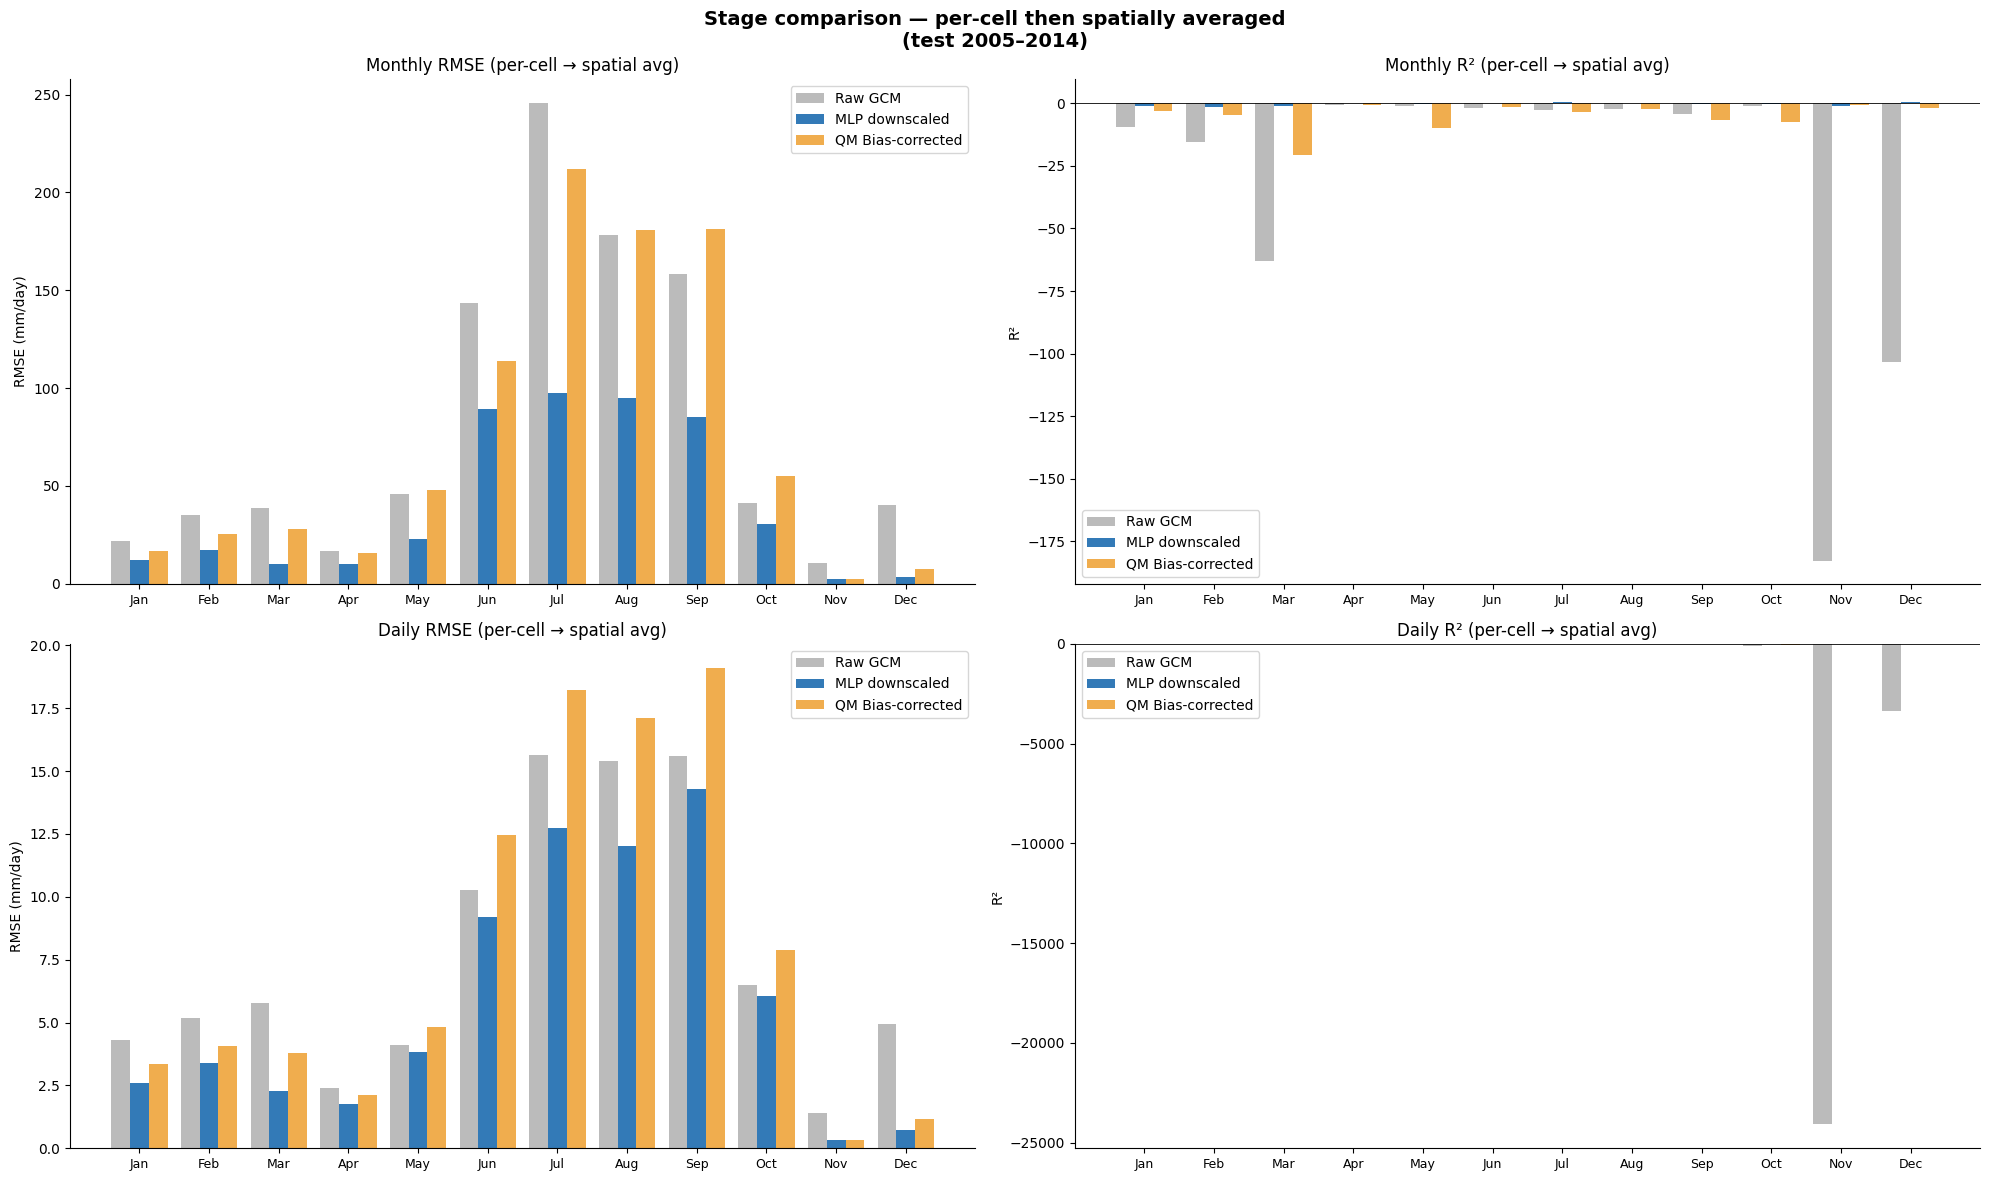

✅ Saved → stage_bars_percell_avg.png


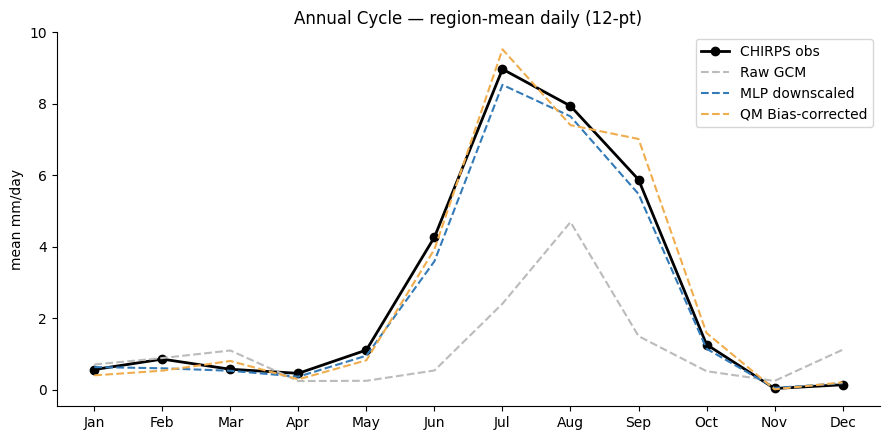

✅ Saved → annual_cycle.png


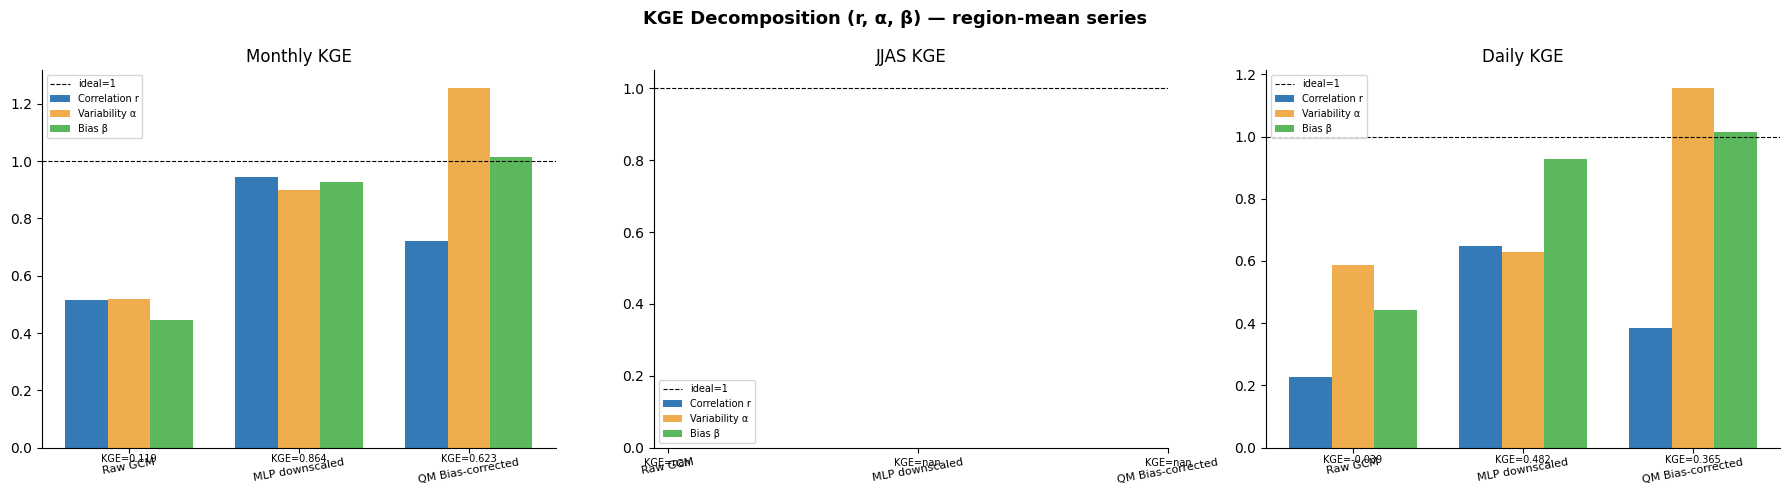

✅ Saved → kge_decomposition.png


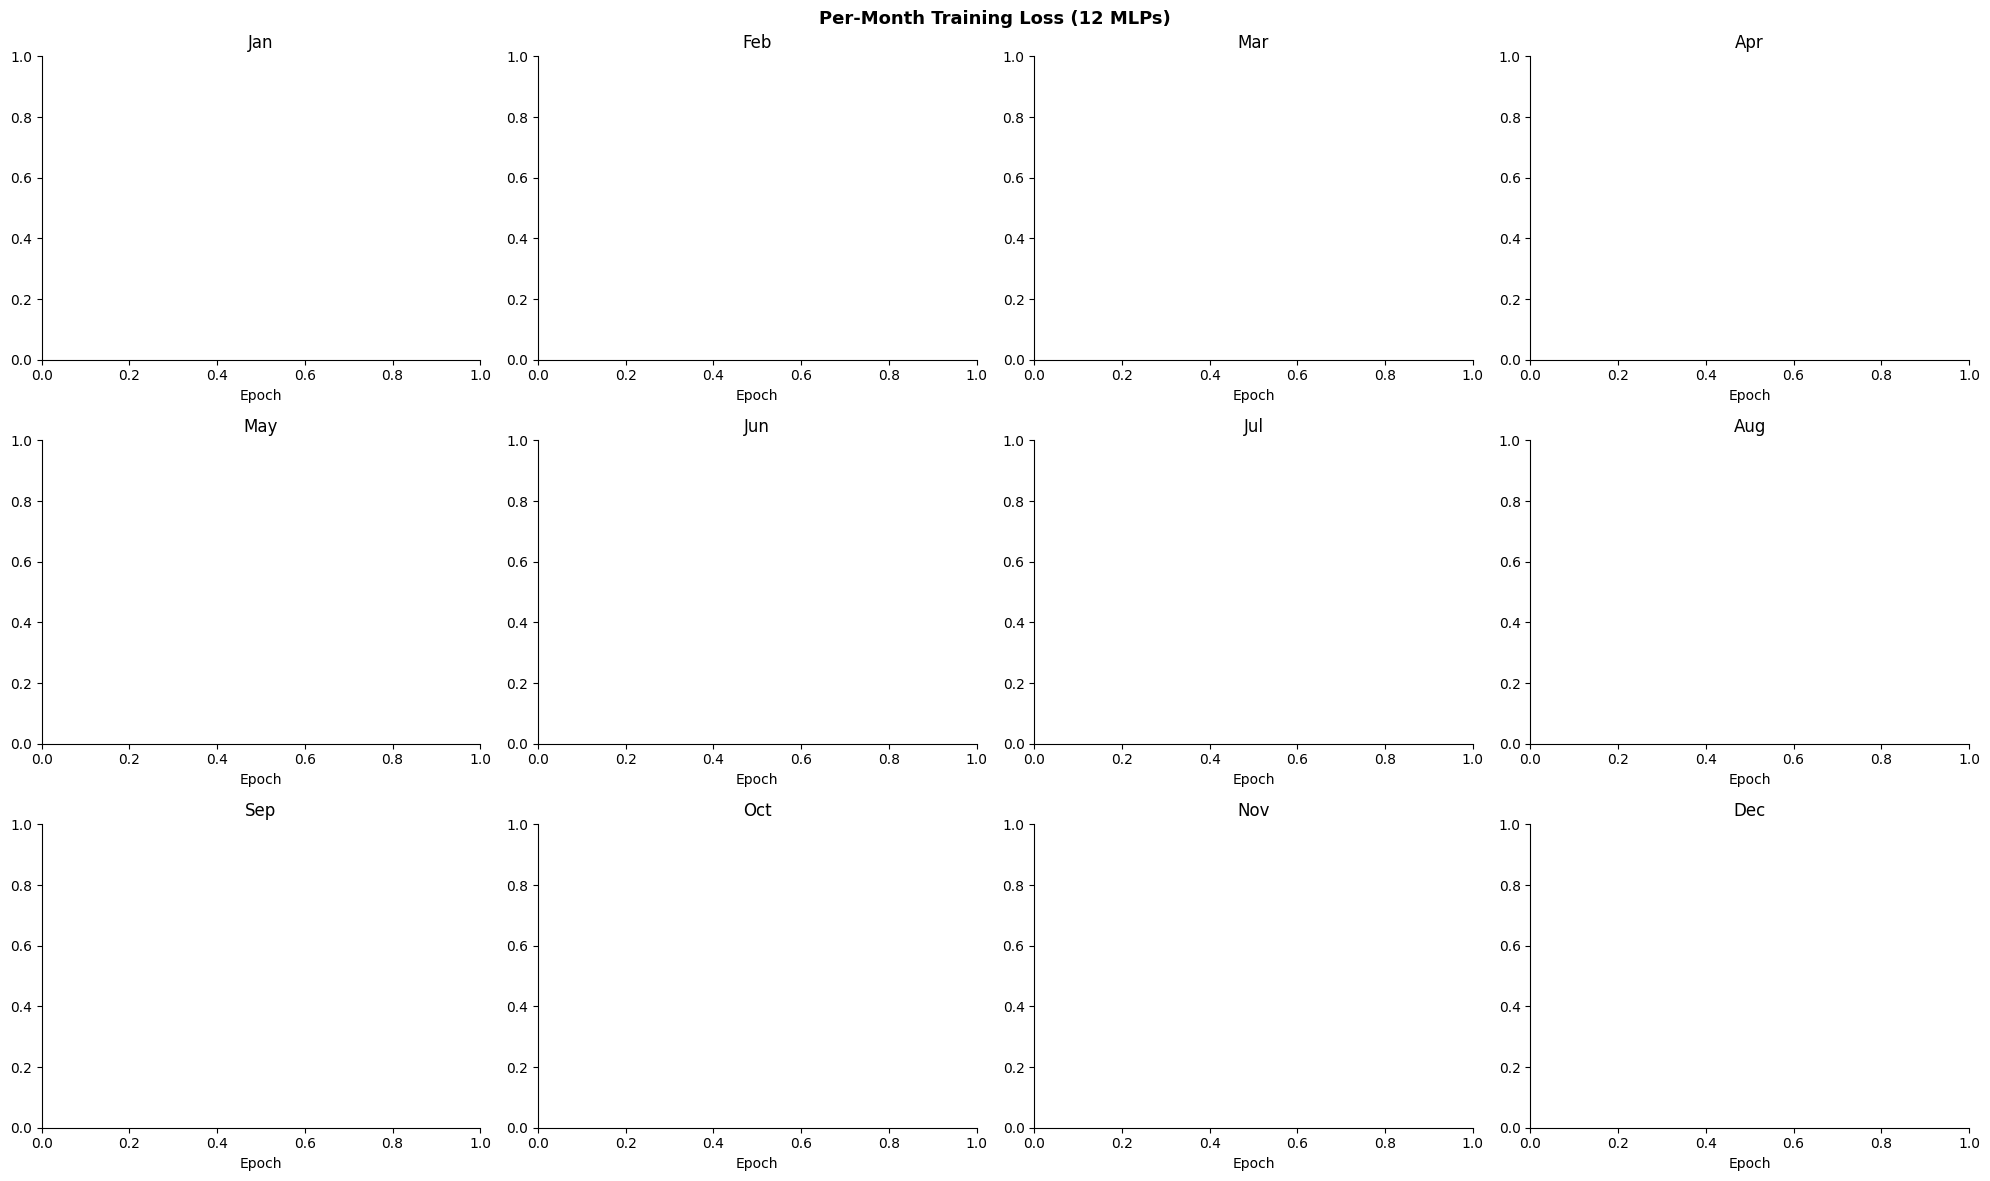

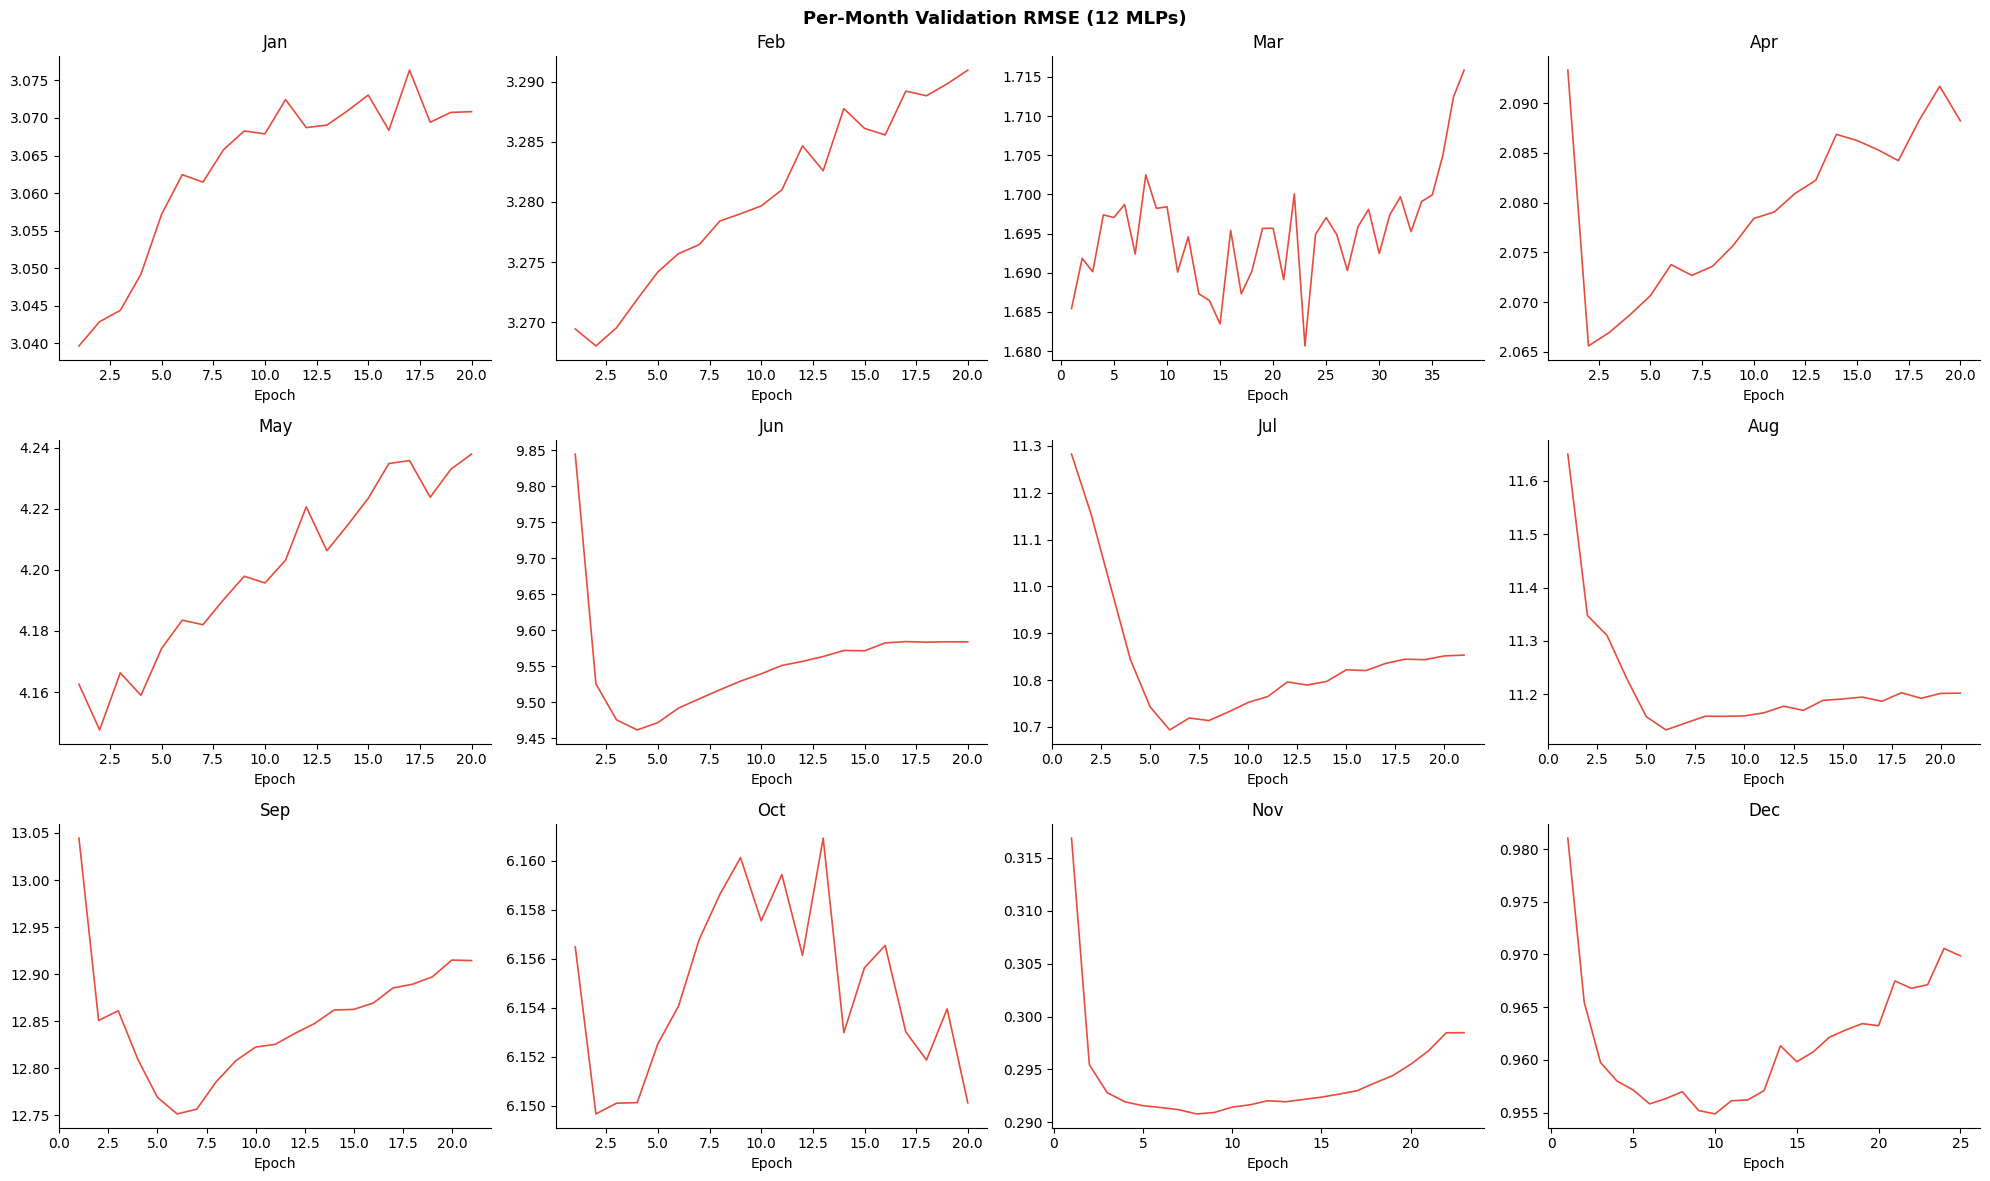

✅ Saved → loss_curves.png, val_rmse_curves.png


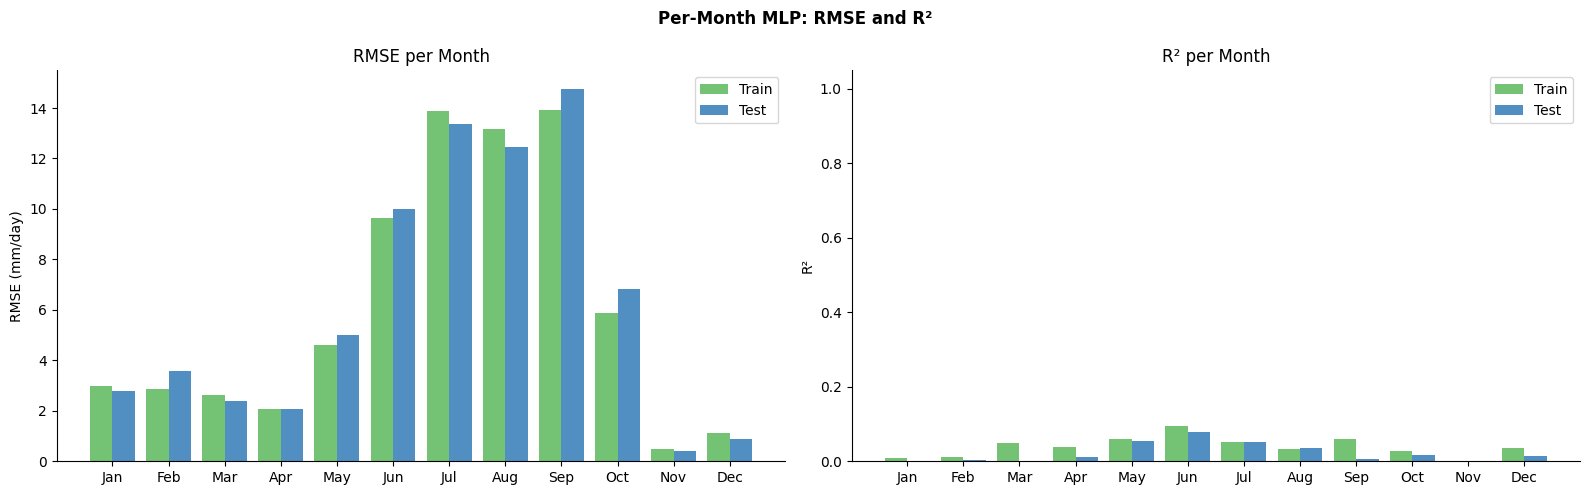

✅ Saved → permonth_metrics.png

✅ All metrics saved → /kaggle/working/region_bcsd_output/metrics_revised.csv

✅ Revised evaluation complete.


In [9]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 5 — EVALUATION (LOW-RAM version for 0.05° CHIRPS)  [BCSD wiring]               ║
# ║  Computes all metrics ON-THE-FLY per month — never stores full daily   ║
# ║  arrays.  Peak RAM ≈ 1 month of data (~400 MB) instead of ~5 GB.      ║
# ║  Adapted for 12 per-month MLP pipeline.                               ║
# ╚══════════════════════════════════════════════════════════════════════╝
import os, gc
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

gc.collect()

# ── (re)load QM TFs so this cell is standalone ──────────────────────────
if "tf_store" not in globals() or not tf_store:
    if os.path.exists(QM1_TF_PATH):
        with np.load(QM1_TF_PATH) as z:
            tf_store = {k: z[k] for k in z.files}
        print(f"✅ Loaded QM transfer functions for {len(tf_store)//2} month(s)")
    else:
        raise FileNotFoundError(f"QM transfer file not found: {QM1_TF_PATH}")

EVAL_YEARS = range(TEST_START, TEST_END + 1)
EVAL_NC_MLP = MLP_TEST_NC

# ── reload 1° QM TFs if needed ──────────────────────────────────────
if "qm1" not in globals() or not qm1:
    if os.path.exists(QM1_TF_PATH):
        with np.load(QM1_TF_PATH) as z:
            qm1 = {k: z[k] for k in z.files}
        print(f"Loaded 1° QM transfer functions for {len(qm1)//2} month(s)")

STAGES = ["raw", "mlp", "bias"]
LABELS = {"raw": "Raw GCM", "mlp": "MLP downscaled", "bias": "QM Bias-corrected"}
COLORS = {"raw": "#bbbbbb", "mlp": "#337ab7", "bias": "#f0ad4e"}

# ── metric helpers ───────────────────────────────────────────────────────
def _rmse_e(o, p): return float(np.sqrt(np.nanmean((o - p) ** 2)))
def _r2_e(o, p):
    ss = np.nansum((o - np.nanmean(o)) ** 2)
    return float(1 - np.nansum((o - p) ** 2) / ss) if ss > 0 else np.nan
def _corr_e(o, p):
    if o.size < 2 or np.nanstd(o) == 0 or np.nanstd(p) == 0: return np.nan
    return float(np.corrcoef(o, p)[0, 1])
def _kge_components_e(o, p):
    if o.size < 2: return np.nan, np.nan, np.nan, np.nan
    r = _corr_e(o, p)
    a = float(np.nanstd(p) / np.nanstd(o)) if np.nanstd(o) > 0 else np.nan
    b = float(np.nanmean(p) / np.nanmean(o)) if np.nanmean(o) != 0 else np.nan
    if any(np.isnan(v) for v in [r, a, b]): return np.nan, r, a, b
    kge = float(1 - np.sqrt((r - 1)**2 + (a - 1)**2 + (b - 1)**2))
    return kge, r, a, b

# ════════════════════════════════════════════════════════════════════════════
#  SINGLE PASS: compute ALL metrics per-month, store only scalars
# ════════════════════════════════════════════════════════════════════════════
print("Computing all metrics in single low-RAM pass …", flush=True)

# Scalar accumulators (tiny — 12 floats each)
monthly_rmse   = {s: np.full(12, np.nan) for s in STAGES}
monthly_r2     = {s: np.full(12, np.nan) for s in STAGES}
daily_rmse     = {s: np.full(12, np.nan) for s in STAGES}
daily_r2       = {s: np.full(12, np.nan) for s in STAGES}
clim_sum       = {s: np.zeros(n5)  for s in STAGES}
obs_clim_sum   = np.zeros(n5)
reg_mon_sum    = {s: np.zeros(12) for s in STAGES}
obs_reg_mon_sum = np.zeros(12)
reg_mon_cnt    = np.zeros(12)
total_days     = 0

# For KGE: region-mean series (only scalars per year-month — tiny)
mon_series     = {s: [] for s in STAGES}
obs_mon_list   = []
daily_reg_series = {s: [] for s in STAGES}
obs_daily_reg    = []

# Spatial clim maps: 12 × n5 (small — ~700 KB each)
obs_clim_maps  = {}
pred_clim_maps = {s: {} for s in STAGES}

dsm = xr.open_dataset(EVAL_NC_MLP)

for month in range(1, 13):
    g1, doy, dates = load_month("gcm1", list(EVAL_YEARS), month)
    obs            = load_month("chr5", list(EVAL_YEARS), month)[0]
    if g1 is None or obs is None:
        print(f"  {MONTH_NAMES[month-1]}: skip", flush=True); continue

    da_mlp = dsm["pr"].sel(time=dsm["pr"].time.dt.month == month)
    n = min(len(g1), len(obs), len(da_mlp.time))

    mk = f"m{month:02d}"
    raw   = bc1_to_005(g1[:n])
    mlp   = da_mlp.values[:n, WIN5["ii"], WIN5["jj"]]
    bias  = bc1_to_005(qm_apply(g1[:n], qm1[f"{mk}_obs_q"], qm1[f"{mk}_his_q"]))
    obs_n = obs[:n]
    yrs   = dates[:n].year.values
    preds = {"raw": raw, "mlp": mlp, "bias": bias}

    obs_v = np.where(np.isfinite(obs_n) & (obs_n >= 0), obs_n, np.nan)

    # ── DAILY per-cell metrics (compute now, store only the 1 scalar) ──
    for s in STAGES:
        p_v = np.where(np.isfinite(preds[s]) & (preds[s] >= 0), preds[s], np.nan)
        # per-cell RMSE & R² across all days this month
        cell_rmse, cell_r2 = [], []
        for c in range(n5):
            oc, pc = obs_v[:, c], p_v[:, c]
            v = np.isfinite(oc) & np.isfinite(pc)
            if v.sum() < 2: continue
            cell_rmse.append(_rmse_e(oc[v], pc[v]))
            cell_r2.append(_r2_e(oc[v], pc[v]))
        if cell_rmse:
            daily_rmse[s][month-1] = float(np.nanmean(cell_rmse))
            daily_r2[s][month-1]   = float(np.nanmean(cell_r2))

    # ── MONTHLY metrics (per-year totals → per-cell metric → avg) ──────
    for s in STAGES:
        yr_metrics_rmse, yr_metrics_r2 = [], []
        for yr in np.unique(yrs):
            sel = yrs == yr
            o_tot = np.nansum(obs_n[sel], axis=0)
            p_tot = np.nansum(preds[s][sel], axis=0)
            vv = np.isfinite(o_tot) & np.isfinite(p_tot)
            if vv.sum() == 0: continue
            yr_metrics_rmse.append(_rmse_e(o_tot[vv], p_tot[vv]))
            yr_metrics_r2.append(_r2_e(o_tot[vv], p_tot[vv]))
        if yr_metrics_rmse:
            monthly_rmse[s][month-1] = float(np.nanmean(yr_metrics_rmse))
            monthly_r2[s][month-1]   = float(np.nanmean(yr_metrics_r2))

    # ── region-mean monthly series (for KGE — one scalar per yr-month) ─
    for yr in np.unique(yrs):
        sel = yrs == yr
        obs_mon_list.append(float(np.nanmean(np.nansum(obs_n[sel], axis=0))))
        for s in STAGES:
            mon_series[s].append(float(np.nanmean(np.nansum(preds[s][sel], axis=0))))

    # ── region-mean daily series (for daily KGE — one scalar per day) ──
    obs_daily_reg.append(np.nanmean(obs_v, axis=1))
    for s in STAGES:
        daily_reg_series[s].append(np.nanmean(
            np.where(np.isfinite(preds[s]) & (preds[s]>=0), preds[s], np.nan), axis=1))

    # ── climatology accumulators ───────────────────────────────────────
    obs_clim_sum += np.nansum(obs_v, axis=0)
    total_days   += n
    for s in STAGES:
        clim_sum[s] += np.nansum(
            np.where(np.isfinite(preds[s]) & (preds[s]>=0), preds[s], np.nan), axis=0)

    # ── spatial climatology maps (one per month — small) ───────────────
    obs_clim_maps[month] = np.nanmean(obs_v, axis=0)
    for s in STAGES:
        pred_clim_maps[s][month] = np.nanmean(
            np.where(np.isfinite(preds[s]) & (preds[s]>=0), preds[s], np.nan), axis=0)

    # ── annual cycle accumulators ──────────────────────────────────────
    obs_reg_mon_sum[month-1] += float(np.nanmean(obs_v))
    reg_mon_cnt[month-1]     += 1
    for s in STAGES:
        reg_mon_sum[s][month-1] += float(
            np.nanmean(np.where(np.isfinite(preds[s]) & (preds[s]>=0), preds[s], np.nan)))

    # free this month's data
    del raw, mlp, bias, obs_n, obs_v, preds, da_mlp
    gc.collect()
    print(f"  {MONTH_NAMES[month-1]} ✓", end="  ", flush=True)

dsm.close(); gc.collect()
print("\n✓ single-pass collection done\n")

# ── derived scalars ──────────────────────────────────────────────────────
obs_clim     = obs_clim_sum / max(total_days, 1)
clim_percell = {s: clim_sum[s] / max(total_days, 1) for s in STAGES}
cnt = np.where(reg_mon_cnt == 0, 1, reg_mon_cnt)
obs_reg_mon  = obs_reg_mon_sum / cnt
reg_mon_mean = {s: reg_mon_sum[s] / cnt for s in STAGES}

# Monthly KGE
obs_mon_arr = np.array(obs_mon_list)
monthly_kge = {}
for s in STAGES:
    kge, r, a, b = _kge_components_e(obs_mon_arr, np.array(mon_series[s]))
    monthly_kge[s] = {"KGE": kge, "r": r, "alpha": a, "beta": b}

# Spatial climatology corr (12 maps concatenated)
valid_months = sorted(obs_clim_maps.keys())
spatial_clim_corr = {}
obs_vec = np.concatenate([obs_clim_maps[m] for m in valid_months])
for s in STAGES:
    p_vec = np.concatenate([pred_clim_maps[s][m] for m in valid_months if m in pred_clim_maps[s]])
    o_vec = np.concatenate([obs_clim_maps[m] for m in valid_months if m in pred_clim_maps[s]])
    v = np.isfinite(o_vec) & np.isfinite(p_vec)
    spatial_clim_corr[s] = _corr_e(o_vec[v], p_vec[v])

# Annual cycle corr
annual_cycle_corr = {s: _corr_e(obs_reg_mon, reg_mon_mean[s]) for s in STAGES}

# Annual pattern corr
annual_pattern_corr = {}
v_ap = np.isfinite(obs_clim)
for s in STAGES:
    vv = v_ap & np.isfinite(clim_percell[s])
    annual_pattern_corr[s] = _corr_e(obs_clim[vv], clim_percell[s][vv])

# JJAS KGE & R²
jjas_idx = []
k = 0
for month in range(1, 13):
    g1, _, _ = load_month("gcm1", list(EVAL_YEARS), month)
    obs     = load_month("chr5", list(EVAL_YEARS), month)[0]
    if g1 is None or obs is None: continue
    n2 = min(len(g1), len(obs))
    if month in [6, 7, 8, 9]:
        jjas_idx.extend(range(k, k + n2))
    k += n2

jjas_kge, jjas_r2 = {}, {}
for s in STAGES:
    ms = np.array(mon_series[s])
    if not jjas_idx or len(ms) == 0:
        jjas_kge[s] = {"KGE": np.nan, "r": np.nan, "alpha": np.nan, "beta": np.nan}
        jjas_r2[s] = np.nan; continue
    vi = [i for i in jjas_idx if i < len(ms) and i < len(obs_mon_arr)]
    o_j, p_j = obs_mon_arr[vi], ms[vi]
    vm = np.isfinite(o_j) & np.isfinite(p_j)
    kge, r, a, b = _kge_components_e(o_j[vm], p_j[vm])
    jjas_kge[s] = {"KGE": kge, "r": r, "alpha": a, "beta": b}
    jjas_r2[s] = _r2_e(o_j[vm], p_j[vm])

# Daily KGE
obs_d = np.concatenate(obs_daily_reg)
daily_kge = {}
for s in STAGES:
    pd_arr = np.concatenate(daily_reg_series[s])
    kge, r, a, b = _kge_components_e(obs_d, pd_arr)
    daily_kge[s] = {"KGE": kge, "r": r, "alpha": a, "beta": b}

# ════════════════════════════════════════════════════════════════════════════
# SECTION 7 ── PRINT FULL METRICS TABLE
# ════════════════════════════════════════════════════════════════════════════
yr0, yr1 = EVAL_YEARS.start, EVAL_YEARS.stop - 1
print(f"\n{'='*72}")
print(f"  REVISED METRICS TABLE  (test {yr0}–{yr1})")
print(f"{'='*72}")

def _fmt(v): return f"{v:8.4f}" if np.isfinite(v) else "     nan"

header = f"{'Metric':<38}" + "".join(f"  {LABELS[s]:>18}" for s in STAGES)
print(header); print("-"*len(header))

print("\n── MONTHLY ──────────────────────────────────────────────────────────")
for m in range(1, 13):
    print(f"  Monthly RMSE {MONTH_NAMES[m-1]:<4}  (per-cell→avg)  "
          + "  ".join([_fmt(monthly_rmse[s][m-1]) for s in STAGES]))
for m in range(1, 13):
    print(f"  Monthly R²   {MONTH_NAMES[m-1]:<4}  (per-cell→avg)  "
          + "  ".join([_fmt(monthly_r2[s][m-1]) for s in STAGES]))
print(f"\n  {'Metric':<38}" + "".join(f"  {LABELS[s]:>18}" for s in STAGES))
print("  " + "-"*78)
for key in ["KGE", "r", "alpha", "beta"]:
    row = [monthly_kge[s][key] for s in STAGES]
    print(f"  Monthly {key:<30}" + "".join([f"  {_fmt(v):>18}" for v in row]))

print("\n── SPATIAL & ANNUAL CYCLE ────────────────────────────────────────────")
print(f"  {'Spatial Climatology Corr (12 maps)':<38}" +
      "".join(f"  {_fmt(spatial_clim_corr[s]):>18}" for s in STAGES))
print(f"  {'Annual Cycle Corr (12-pt region mean)':<38}" +
      "".join(f"  {_fmt(annual_cycle_corr[s]):>18}" for s in STAGES))
print(f"  {'Annual Pattern Corr (per-cell mean)':<38}" +
      "".join(f"  {_fmt(annual_pattern_corr[s]):>18}" for s in STAGES))

print("\n── JJAS ──────────────────────────────────────────────────────────────")
for key in ["KGE", "r", "alpha", "beta"]:
    row = [jjas_kge[s][key] for s in STAGES]
    print(f"  JJAS {key:<33}" + "".join([f"  {_fmt(v):>18}" for v in row]))
print(f"  {'JJAS R² (region-mean series)':<38}" +
      "".join(f"  {_fmt(jjas_r2[s]):>18}" for s in STAGES))

print("\n── DAILY ─────────────────────────────────────────────────────────────")
for m in range(1, 13):
    print(f"  Daily RMSE {MONTH_NAMES[m-1]:<4}  (per-cell→avg)  "
          + "  ".join([_fmt(daily_rmse[s][m-1]) for s in STAGES]))
for m in range(1, 13):
    print(f"  Daily R²   {MONTH_NAMES[m-1]:<4}  (per-cell→avg)  "
          + "  ".join([_fmt(daily_r2[s][m-1]) for s in STAGES]))
for key in ["KGE", "r", "alpha", "beta"]:
    row = [daily_kge[s][key] for s in STAGES]
    print(f"  Daily {key:<33}" + "".join([f"  {_fmt(v):>18}" for v in row]))

# ════════════════════════════════════════════════════════════════════════════
# SECTION 8 ── STAGE BAR CHARTS
# ════════════════════════════════════════════════════════════════════════════
x = np.arange(12); w = 0.27
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle(f"Stage comparison — per-cell then spatially averaged\n"
             f"(test {yr0}–{yr1})", fontsize=14, fontweight="bold")

ax = axes[0, 0]
for i, s in enumerate(STAGES):
    ax.bar(x + (i-1)*w, monthly_rmse[s], w, label=LABELS[s], color=COLORS[s])
ax.set_xticks(x); ax.set_xticklabels(MONTH_NAMES, fontsize=9)
ax.set_title("Monthly RMSE (per-cell → spatial avg)"); ax.set_ylabel("RMSE (mm/day)")
ax.legend(); ax.spines[["top","right"]].set_visible(False); ax.axhline(0, color="k", lw=.6)

ax = axes[0, 1]
for i, s in enumerate(STAGES):
    ax.bar(x + (i-1)*w, monthly_r2[s], w, label=LABELS[s], color=COLORS[s])
ax.set_xticks(x); ax.set_xticklabels(MONTH_NAMES, fontsize=9)
ax.set_title("Monthly R² (per-cell → spatial avg)"); ax.set_ylabel("R²")
ax.legend(); ax.spines[["top","right"]].set_visible(False); ax.axhline(0, color="k", lw=.6)

ax = axes[1, 0]
for i, s in enumerate(STAGES):
    ax.bar(x + (i-1)*w, daily_rmse[s], w, label=LABELS[s], color=COLORS[s])
ax.set_xticks(x); ax.set_xticklabels(MONTH_NAMES, fontsize=9)
ax.set_title("Daily RMSE (per-cell → spatial avg)"); ax.set_ylabel("RMSE (mm/day)")
ax.legend(); ax.spines[["top","right"]].set_visible(False); ax.axhline(0, color="k", lw=.6)

ax = axes[1, 1]
for i, s in enumerate(STAGES):
    ax.bar(x + (i-1)*w, daily_r2[s], w, label=LABELS[s], color=COLORS[s])
ax.set_xticks(x); ax.set_xticklabels(MONTH_NAMES, fontsize=9)
ax.set_title("Daily R² (per-cell → spatial avg)"); ax.set_ylabel("R²")
ax.legend(); ax.spines[["top","right"]].set_visible(False); ax.axhline(0, color="k", lw=.6)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/stage_bars_percell_avg.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → stage_bars_percell_avg.png")

# ════════════════════════════════════════════════════════════════════════════
# SECTION 9 ── ANNUAL CYCLE LINE PLOT
# ════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(range(1, 13), obs_reg_mon, "k-o", lw=2, label="CHIRPS obs")
for s in STAGES:
    ax.plot(range(1, 13), reg_mon_mean[s], "--", color=COLORS[s], label=LABELS[s])
ax.set_xticks(range(1, 13)); ax.set_xticklabels(MONTH_NAMES)
ax.set_ylabel("mean mm/day"); ax.set_title("Annual Cycle — region-mean daily (12-pt)")
ax.legend(); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/annual_cycle.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → annual_cycle.png")

# ════════════════════════════════════════════════════════════════════════════
# SECTION 10 ── KGE DECOMPOSITION PLOT
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("KGE Decomposition (r, α, β) — region-mean series", fontsize=13, fontweight="bold")
kge_sets = [("Monthly KGE", monthly_kge), ("JJAS KGE", jjas_kge), ("Daily KGE", daily_kge)]
comp_labels = {"r": "Correlation r", "alpha": "Variability α", "beta": "Bias β"}
comp_colors = {"r": "#337ab7", "alpha": "#f0ad4e", "beta": "#5cb85c"}

for ax, (title, kge_dict) in zip(axes, kge_sets):
    xs = np.arange(len(STAGES)); bw = 0.25
    for j, comp in enumerate(["r", "alpha", "beta"]):
        vals = [kge_dict[s][comp] for s in STAGES]
        ax.bar(xs + (j-1)*bw, vals, bw, label=comp_labels[comp], color=comp_colors[comp])
    ax.axhline(1, color="k", lw=0.8, ls="--", label="ideal=1")
    ax.axhline(0, color="k", lw=0.4)
    ax.set_xticks(xs); ax.set_xticklabels([LABELS[s] for s in STAGES], fontsize=8, rotation=10)
    ax.set_title(title); ax.legend(fontsize=7)
    ax.spines[["top","right"]].set_visible(False)
    for j2, s in enumerate(STAGES):
        kge_v = kge_dict[s]["KGE"]
        ax.text(j2, ax.get_ylim()[0]*0.97 if ax.get_ylim()[0] < 0 else -0.05,
                f"KGE={kge_v:.3f}", ha="center", fontsize=7, color="black")

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/kge_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → kge_decomposition.png")

# ════════════════════════════════════════════════════════════════════════════
# SECTION 11 ── TRAINING CURVES  (adapted for 12 per-month MLPs)
# ════════════════════════════════════════════════════════════════════════════
# Try in-memory epoch_metrics first (available if Cell 4 just ran),
# otherwise load per-month CSVs from disk.
if "epoch_metrics" not in globals() or not epoch_metrics:
    epoch_metrics = {}
    for month in range(1, 13):
        mstr = f"m{month:02d}"
        ep_csv = os.path.join(OUT_DIR, f"epoch_{mstr}.csv")
        if os.path.exists(ep_csv):
            d = pd.read_csv(ep_csv)
            epoch_metrics[month] = {
                "train_loss": d["train_loss"].tolist(),
                "val_rmse":   d["val_rmse"].dropna().tolist(),
            }
    if epoch_metrics:
        print(f"✅ Loaded epoch metrics from CSV for {len(epoch_metrics)} month(s)")

if epoch_metrics:
    # 3×4 grid: per-month training loss
    fig, axes = plt.subplots(3, 4, figsize=(20, 12)); axes_flat = axes.ravel()
    fig.suptitle("Per-Month Training Loss (12 MLPs)", fontsize=13, fontweight="bold")
    for m in range(1, 13):
        ax = axes_flat[m-1]
        if m in epoch_metrics and epoch_metrics[m].get("train_loss"):
            vals = epoch_metrics[m]["train_loss"]
            ax.plot(range(1, len(vals)+1), vals, color="#337ab7", lw=1.2)
        ax.set_title(MONTH_NAMES[m-1]); ax.set_xlabel("Epoch")
        ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/loss_curves.png", dpi=150, bbox_inches="tight"); plt.show()

    # 3×4 grid: per-month val RMSE
    fig, axes = plt.subplots(3, 4, figsize=(20, 12)); axes_flat = axes.ravel()
    fig.suptitle("Per-Month Validation RMSE (12 MLPs)", fontsize=13, fontweight="bold")
    for m in range(1, 13):
        ax = axes_flat[m-1]
        if m in epoch_metrics and epoch_metrics[m].get("val_rmse"):
            vals = epoch_metrics[m]["val_rmse"]
            ax.plot(range(1, len(vals)+1), vals, color="#e74c3c", lw=1.2)
        ax.set_title(MONTH_NAMES[m-1]); ax.set_xlabel("Epoch")
        ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/val_rmse_curves.png", dpi=150, bbox_inches="tight"); plt.show()
    print("✅ Saved → loss_curves.png, val_rmse_curves.png")

    # Summary bar: per-month Train/Test RMSE & R² (from summary dict)
    if "summary" in globals() and summary:
        months = [m for m in range(1, 13) if m in summary]
        if months:
            x2, w2 = np.arange(len(months)), 0.4
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
            fig.suptitle("Per-Month MLP: RMSE and R²", fontsize=12, fontweight="bold")
            for ax, i_tr, i_te, ylab, ttl, ylim in [
                (ax1, 0, 2, "RMSE (mm/day)", "RMSE per Month", None),
                (ax2, 1, 3, "R²",            "R² per Month",   (0, 1.05))]:
                ax.bar(x2-w2/2, [summary[m][i_tr] for m in months], w2,
                       label="Train", color="#5cb85c", alpha=.85)
                ax.bar(x2+w2/2, [summary[m][i_te] for m in months], w2,
                       label="Test",  color="#337ab7", alpha=.85)
                ax.set_xticks(x2); ax.set_xticklabels([MONTH_NAMES[m-1] for m in months])
                ax.set_ylabel(ylab); ax.set_title(ttl)
                if ylim: ax.set_ylim(*ylim)
                ax.legend(); ax.spines[["top","right"]].set_visible(False)
            plt.tight_layout()
            plt.savefig(f"{OUT_DIR}/permonth_metrics.png", dpi=150, bbox_inches="tight"); plt.show()
            print("✅ Saved → permonth_metrics.png")
else:
    print("ℹ No epoch metrics found — skipping training curves")

# ════════════════════════════════════════════════════════════════════════════
# SECTION 12 ── SAVE METRICS TO CSV
# ════════════════════════════════════════════════════════════════════════════
rows = []
for m in range(1, 13):
    rows.append({"metric": f"Monthly RMSE {MONTH_NAMES[m-1]} (per-cell→avg)", "method": "per-cell→spatial avg",
                 **{LABELS[s]: monthly_rmse[s][m-1] for s in STAGES}})
for m in range(1, 13):
    rows.append({"metric": f"Monthly R² {MONTH_NAMES[m-1]} (per-cell→avg)", "method": "per-cell→spatial avg",
                 **{LABELS[s]: monthly_r2[s][m-1] for s in STAGES}})
for key in ["KGE", "r", "alpha", "beta"]:
    rows.append({"metric": f"Monthly {key} (region-mean series)", "method": "region-mean",
                 **{LABELS[s]: monthly_kge[s][key] for s in STAGES}})
rows.append({"metric": "Spatial Climatology Corr (12 maps concat)", "method": "per-cell spatial",
             **{LABELS[s]: spatial_clim_corr[s] for s in STAGES}})
rows.append({"metric": "Annual Cycle Corr (12-pt region mean)", "method": "region-mean",
             **{LABELS[s]: annual_cycle_corr[s] for s in STAGES}})
rows.append({"metric": "Annual Pattern Corr (per-cell annual mean)", "method": "per-cell spatial",
             **{LABELS[s]: annual_pattern_corr[s] for s in STAGES}})
for key in ["KGE", "r", "alpha", "beta"]:
    rows.append({"metric": f"JJAS {key} (region-mean series)", "method": "region-mean",
                 **{LABELS[s]: jjas_kge[s][key] for s in STAGES}})
rows.append({"metric": "JJAS R² (region-mean JJAS series)", "method": "region-mean",
             **{LABELS[s]: jjas_r2[s] for s in STAGES}})
for m in range(1, 13):
    rows.append({"metric": f"Daily RMSE {MONTH_NAMES[m-1]} (per-cell→avg)", "method": "per-cell→spatial avg",
                 **{LABELS[s]: daily_rmse[s][m-1] for s in STAGES}})
for m in range(1, 13):
    rows.append({"metric": f"Daily R² {MONTH_NAMES[m-1]} (per-cell→avg)", "method": "per-cell→spatial avg",
                 **{LABELS[s]: daily_r2[s][m-1] for s in STAGES}})
for key in ["KGE", "r", "alpha", "beta"]:
    rows.append({"metric": f"Daily {key} (region-mean daily series)", "method": "region-mean",
                 **{LABELS[s]: daily_kge[s][key] for s in STAGES}})

df_metrics = pd.DataFrame(rows)
out_csv = f"{OUT_DIR}/metrics_revised.csv"
df_metrics.to_csv(out_csv, index=False)
print(f"\n✅ All metrics saved → {out_csv}")
print("\n✅ Revised evaluation complete.")


In [10]:
import os
import shutil

folder_to_zip = "/kaggle/working/region_bcsd_output"

zip_path = shutil.make_archive(
    "/kaggle/working/region_bcsd_output",
    "zip",
    folder_to_zip
)

print("ZIP created:", zip_path)
print("Size:", round(os.path.getsize(zip_path)/(1024*1024), 2), "MB")

ZIP created: /kaggle/working/region_bcsd_output.zip
Size: 563.55 MB
